<a href="https://colab.research.google.com/github/Maverick-Ansh/rest-mcts/blob/main/Copy_of_scratchpad.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ReST-MCTS\* built from scratch on 2× T4

**Paper:** *ReST-MCTS\*: LLM Self-Training via Process Reward Guided Tree Search* (Zhang et al., NeurIPS 2024, arXiv 2406.03816) · **Official code:** github.com/THUDM/ReST-MCTS

## The problem

Self-training methods such as STaR, RFT, and ReST-EM work like this: sample solutions, keep the ones with the right final answer, and fine-tune on them. But **a right final answer does not mean every step was right.** Those "false positive" traces go into training anyway. The fix is a **process reward model (PRM)** that scores every step. Training a PRM normally needs a human label on every step, and that does not scale.

## The paper's idea

Run a **tree search** (MCTS\*) guided by a value model. Look at which branches of the tree reach the known correct answer. From the shape of the tree alone you can then compute a target value for *every partial solution*. That target is built from two numbers:

* **did this step lead anywhere correct?** (the hard estimate $r_{s_k}$), and
* **how many steps are still missing?** (the reasoning distance $m_k$).

These inferred values do two jobs:
1. They become **training targets for the value model** (so no human step labels are needed).
2. The correct traces in the tree become **SFT data for the policy**.

Repeat, and both models improve together (Algorithm 1).

## The four components, each built explicitly below

| # | Component | Paper | This notebook |
|---|---|---|---|
| 1 | Quality value $v_k$ and weighted reward $w_{s_k}$ | Eq. 1–2, Thm 1, App. B | Part 1: pure Python, paper's Fig. 3 reproduced number for number |
| 2 | Value model $V_\theta$ (a variant of a PRM) | §3.1, App. E.1, `models/value_models.py` | Part 3: the LLM's last-token **vocab logits → `Linear(vocab, 1)`**, MSE loss |
| 3 | MCTS\* search | App. C.1, Alg. 2, `MCTS/mcts.py` | Part 4: selection (UCB), self-critic, expansion, greedy MC rollout, weighted backprop |
| 4 | Mutual self-training | §3.2, Alg. 1 | Part 6: search → prune → verify → infer values → SFT the policy + train the value model, iterated |

**Setup:** policy $\pi$ = `Qwen2.5-1.5B-Instruct` served by vLLM on GPU 0. Value model $V_\theta$ = the **same backbone** (as in the paper, where MetaMath-Mistral-7B is both policy and value backbone) with LoRA and a vocab head, on GPU 1. Task = **MATH**, the paper's main benchmark.

In [ ]:
#@title 0 · Probe the runtime (GPU, RAM, disk, libraries)
import subprocess, sys, os, datetime, shutil
print("now:", datetime.datetime.now())
print(subprocess.run("nvidia-smi --query-gpu=name,memory.total,memory.used --format=csv", shell=True, capture_output=True, text=True).stdout)
print("python", sys.version.split()[0])
print("cpus", os.cpu_count())
print(subprocess.run("free -g | head -2", shell=True, capture_output=True, text=True).stdout)
print("disk free GB:", shutil.disk_usage("/").free // 2**30, "| cwd:", os.getcwd())
for mod in ["torch", "transformers", "vllm", "peft", "datasets", "accelerate"]:
    try:
        m = __import__(mod); print(f"{mod:14s}", m.__version__)
    except Exception as e:
        print(f"{mod:14s}", "MISSING")
print("kaggle input:", os.path.exists("/kaggle/input"), "| colab:", "google.colab" in sys.modules)

now: 2026-09-25 04:24:32.069970
name, memory.total [MiB], memory.used [MiB]
Tesla T4, 15360 MiB, 0 MiB
Tesla T4, 15360 MiB, 0 MiB

python 3.12.13
cpus 4
               total        used        free      shared  buff/cache   available
Mem:              31           1          25           0           5          29

disk free GB: 1119 | cwd: /kaggle/working
torch          2.10.0+cu128
transformers   5.0.0
vllm           MISSING
peft           0.18.1
datasets       4.8.5
accelerate     1.13.0
kaggle input: True | colab: True


In [ ]:
#@title 0b · Internet + tooling probe
import subprocess
def sh(cmd, t=60):
    r = subprocess.run(cmd, shell=True, capture_output=True, text=True, timeout=t)
    return (r.stdout + r.stderr).strip()
print(sh("curl -s -o /dev/null -w 'pypi %{http_code} %{time_total}s\\n' https://pypi.org/simple/vllm/ --max-time 20"))
print(sh("curl -s -o /dev/null -w 'hf   %{http_code} %{time_total}s\\n' https://huggingface.co/api/models/Qwen/Qwen2.5-1.5B-Instruct --max-time 20"))
print(sh("curl -s -o /dev/null -w 'gh   %{http_code} %{time_total}s\\n' https://github.com --max-time 20"))
print("uv:", sh("which uv; uv --version"))
print(sh("ls /kaggle/input 2>/dev/null | head"))
print(sh("pip list 2>/dev/null | grep -i -E 'math.verify|sympy|latex2sympy|openai|requests|graphviz|networkx' "))

pypi 200 0.097202s
hf   200 0.086719s
gh   200 0.098698s
uv: /usr/local/bin/uv
uv 0.11.2 (x86_64-unknown-linux-gnu)

graphviz                                 0.21
networkx                                 3.6.1
openai                                   2.31.0
requests                                 2.32.4
requests-oauthlib                        2.0.0
requests-toolbelt                        1.0.0
sympy                                    1.14.0


In [ ]:
#@title 1b · Poll background installs (re-run until VLLM_OK / MODEL_OK / TEST_OK appear)
print("install alive:", p_install.poll() is None, "| download alive:", p_dl.poll() is None)
print("---- install.log (tail)"); print(sh(f"tail -5 {W}/logs/install.log"))
print("---- download.log (tail)"); print(sh(f"tail -6 {W}/logs/download.log"))

install alive: False | download alive: False
---- install.log (tail)
+ uv pip install --python /kaggle/working/.vllm/bin/python vllm==0.11.0 transformers==4.56.2 -q
+ /kaggle/working/.vllm/bin/python -c 'import vllm, torch; print("VLLM_OK", vllm.__version__, torch.__version__)'
Error in sitecustomize; set PYTHONVERBOSE for traceback:
ModuleNotFoundError: No module named 'wrapt'
VLLM_OK 0.11.0 2.8.0+cu128
---- download.log (tail)
MODEL_OK Qwen/Qwen2.5-1.5B-Instruct /root/.cache/huggingface/hub/models--Qwen--Qwen2.5-1.5B-Instruct/snapshots/989aa7980e4cf806f80c7fef2b1adb7bc71aa306

Generating train split: 100%|██████████| 7500/7500 [00:00<00:00, 88845.06 examples/s]

Generating test split: 100%|██████████| 5000/5000 [00:00<00:00, 225896.14 examples/s]
TRAIN_OK 7500

Generating test split: 100%|██████████| 500/500 [00:00<00:00, 62294.73 examples/s]
TEST_OK 500


In [ ]:
#@title 1 · Background installs: vLLM in its OWN venv (kernel torch stays 2.10), models, datasets
# Why a separate venv: vllm==0.11.0 pins torch 2.8. Installing it into the kernel env would downgrade
# the torch this kernel already imported -> forced restart. A venv keeps both worlds intact:
#   kernel (torch 2.10, transformers 5.0)  -> value model, SFT training, tree bookkeeping
#   venv   (torch 2.8,  vllm 0.11)         -> the policy server (fast batched generation)
import subprocess, os
W = "/kaggle/working/restmcts"; os.makedirs(f"{W}/logs", exist_ok=True)
script = f"""
set -x
uv venv /kaggle/working/.vllm --python 3.12 -q
uv pip install --python /kaggle/working/.vllm/bin/python vllm==0.11.0 transformers==4.56.2 -q
/kaggle/working/.vllm/bin/python -c 'import vllm, torch; print("VLLM_OK", vllm.__version__, torch.__version__)'
"""
open(f"{W}/logs/install.sh", "w").write(script)
p_install = subprocess.Popen(f"bash {W}/logs/install.sh > {W}/logs/install.log 2>&1", shell=True, start_new_session=True)

dl = """
pip install -q math-verify 2>&1 | tail -1
python - <<'EOF'
from huggingface_hub import snapshot_download
for rid in ["Qwen/Qwen2.5-1.5B-Instruct"]:
    p = snapshot_download(rid, allow_patterns=["*.json", "*.safetensors", "*.txt", "merges.txt", "vocab.json"])
    print("MODEL_OK", rid, p)
from datasets import load_dataset
tr = load_dataset("DigitalLearningGmbH/MATH-lighteval", split="train"); print("TRAIN_OK", len(tr))
te = load_dataset("HuggingFaceH4/MATH-500", split="test");            print("TEST_OK", len(te))
EOF
"""
open(f"{W}/logs/download.sh", "w").write(dl)
p_dl = subprocess.Popen(f"bash {W}/logs/download.sh > {W}/logs/download.log 2>&1", shell=True, start_new_session=True)
print("launched install pid", p_install.pid, "| download pid", p_dl.pid)

launched install pid 169 | download pid 170


---
# Part 1 · The quality value $v_k$: the paper's core definition

A solution is a list of steps $s_1, s_2, \dots, s_K$. A **partial solution** is $p_k = [s_1,\dots,s_k]$. The paper wants one number $v_k$ for every partial solution that

* stays inside $[0,1]$,
* goes up when a step is correct and goes down when it is wrong,
* goes up **more** for steps that bring the answer closer,
* reaches $1$ only when the correct final answer has been reached.

**Symbols**

* $r_{s_k}\in[0,1]$: how *wrong* step $k$ is. In self-training this is the **hard estimate**: $r_{s_k}=0$ if some branch of the tree below this step reaches the correct answer, otherwise $r_{s_k}=1$. (In the paper, $r_{s_k} = 1 - r^{HE}_{s_k}$.)
* $m_k$: the **reasoning distance**, meaning the fewest further steps that still reach the correct answer from $p_k$. You cannot observe it directly. You read it off the search tree.

**Eq. 2, weighted reward of step $k$:**
$$w_{s_k} = \frac{1-v_{k-1}}{m_k+1}\,\bigl(1-2r_{s_k}\bigr)$$

**Eq. 1, quality value:**
$$v_0 = 0,\qquad v_k = \max\bigl(v_{k-1}+w_{s_k},\,0\bigr)$$

How to read Eq. 2 term by term:
* $(1-v_{k-1})$ is the **gap still left to close**. A step can never push $v$ past 1 (this is Theorem 1).
* $\frac{1}{m_k+1}$ splits that gap evenly over the steps still needed. If 3 steps remain, this step earns $1/4$ of the gap. The last step ($m_k=0$) earns the whole gap and lands exactly on $v=1$.
* $(1-2r_{s_k})$ is the sign. It is $+1$ for a correct step and $-1$ for a wrong one, so a wrong step loses the same amount a correct step would have gained.

The code cell below implements these two lines and then checks Theorem 1 and Observations 1–3 numerically.

In [ ]:
#@title 1.1 · Eq. 1 + Eq. 2 in code, then Theorem 1 and Observations 1-3 checked numerically
import random, math

def weighted_reward(v_prev, m_k, r_sk):
    """Eq. 2:  w = (1 - v_{k-1}) / (m_k + 1) * (1 - 2 r_sk)"""
    return (1.0 - v_prev) / (m_k + 1) * (1.0 - 2.0 * r_sk)

def quality_value(v_prev, w):
    """Eq. 1:  v_k = max(v_{k-1} + w, 0)"""
    return max(v_prev + w, 0.0)

# --- Theorem 1 (boundedness): w <= 1 - v_prev  and  v in [0, 1].  Fuzz 1,000,000 random cases.
rng = random.Random(0); worst_v, worst_gap = -1, -1
for _ in range(1_000_000):
    v_prev, m, r = rng.random(), rng.randint(0, 20), rng.random()
    w = weighted_reward(v_prev, m, r); v = quality_value(v_prev, w)
    assert 0.0 <= v <= 1.0 and w <= 1 - v_prev + 1e-12
    worst_v = max(worst_v, v); worst_gap = max(worst_gap, w - (1 - v_prev))
print(f"Theorem 1 holds on 1e6 random cases: max v seen = {worst_v:.6f}, max (w - (1-v_prev)) = {worst_gap:.2e}")

# --- Observation 1: more steps left (bigger m) -> smaller reward for the same correct step
print("\nObs 1  v_prev=0.2, correct step (r=0):", {m: round(weighted_reward(0.2, m, 0), 3) for m in range(5)})
# --- Observation 2: w falls as the step becomes more wrong (r rises)
print("Obs 2  v_prev=0.2, m=1:               ", {r: round(weighted_reward(0.2, 1, r), 3) for r in (0, .25, .5, .75, 1)})
# --- Observation 3: v -> 1 only when r=0 AND m=0 (the step that reaches the correct answer)
print("Obs 3  v after a step from v_prev=0.6: ", {f"m={m},r={r}": round(quality_value(0.6, weighted_reward(0.6, m, r)), 3)
                                               for m in (0, 1) for r in (0, 1)})

# --- A clean K-step correct solution: every step earns 1/K and v_k = k/K  (paper App. B.2, Eq. 20)
K = 5; v = 0.0; traj = []
for k in range(1, K + 1):
    w = weighted_reward(v, K - k, 0); v = quality_value(v, w); traj.append((k, round(w, 4), round(v, 4)))
print(f"\nClean K={K} trace (k, w_k, v_k):", traj, " -> w_k = 1/K and v_k = k/K exactly")

# --- Eq. 21/22: a WRONG step inserted after k correct ones (r=1, m stays K-k): closed form vs recursion
for K, k in [(5, 2), (8, 5), (4, 1)]:
    v_k = k / K
    w_rec = weighted_reward(v_k, K - k, 1); v_rec = quality_value(v_k, w_rec)
    w_cf = -(K - k) / (K - k + 1) / K                       # Eq. 21
    v_cf = max(0, (k - 1) / K + 1 / (K * (K - k + 1)))      # Eq. 22
    print(f"K={K}, wrong step after k={k}:  w rec {w_rec:+.4f} vs Eq.21 {w_cf:+.4f} | v rec {v_rec:.4f} vs Eq.22 {v_cf:.4f}")

Theorem 1 holds on 1e6 random cases: max v seen = 1.000000, max (w - (1-v_prev)) = -4.08e-07

Obs 1  v_prev=0.2, correct step (r=0): {0: 0.8, 1: 0.4, 2: 0.267, 3: 0.2, 4: 0.16}
Obs 2  v_prev=0.2, m=1:                {0: 0.4, 0.25: 0.2, 0.5: 0.0, 0.75: -0.2, 1: -0.4}
Obs 3  v after a step from v_prev=0.6:  {'m=0,r=0': 1.0, 'm=0,r=1': 0.2, 'm=1,r=0': 0.8, 'm=1,r=1': 0.4}

Clean K=5 trace (k, w_k, v_k): [(1, 0.2, 0.2), (2, 0.2, 0.4), (3, 0.2, 0.6), (4, 0.2, 0.8), (5, 0.2, 1.0)]  -> w_k = 1/K and v_k = k/K exactly
K=5, wrong step after k=2:  w rec -0.1500 vs Eq.21 -0.1500 | v rec 0.2500 vs Eq.22 0.2500
K=8, wrong step after k=5:  w rec -0.0938 vs Eq.21 -0.0938 | v rec 0.5312 vs Eq.22 0.5312
K=4, wrong step after k=1:  w rec -0.1875 vs Eq.21 -0.1875 | v rec 0.0625 vs Eq.22 0.0625


## 1.2 · Inferring $v$ for every node of a verified tree (§3.2, Fig. 3/4)

This is the step that replaces human labels. The input is a search tree whose finished leaves have been checked against the known answer. The algorithm makes three passes. It is ported line for line from the official `treeNode.get_full_value_samples_vm` in `MCTS/base.py`.

1. **From each correct leaf, walk up.** The leaf gets `min_steps = 1`, which means $m=0$. Each ancestor gets `min(children) + 1`, and every node on the way gets `he = 1` (it can reach a correct answer).
2. **From each wrong leaf, walk up** to the nearest node that *does* have a correct descendant, and copy that node's `min_steps` down the whole wrong branch. This is the paper's rule "$m_k$ set to the same as $m_{k-1}$ if $r^{HE}_{s_k}=0$". A wrong step leaves you exactly as far from the answer as you were before it.
3. **Walk down from the root** and apply Eq. 1–2. Here $r = -1$ for a wrong node and $+1$ for a right one, and the official code's `min_steps` is exactly the paper's $m_k + 1$.

Branches that never finished stay at `min_steps = 1024` and are dropped. That is the "prune" in Fig. 4.

Below: the paper's own dice example from Fig. 3, rebuilt node by node. The printed $m$ and $v$ values should match the labels in the paper's figure.

In [ ]:
#@title 1.2 · TreeNode + official value inference (port of MCTS/base.py) + the paper's Fig. 3 tree
import itertools
INF_STEPS = 1024
_node_ids = itertools.count()

class TreeNode:
    """One node = one partial solution p_k.  Field names follow the official treeNode."""
    def __init__(self, step="", parent=None):
        self.id = next(_node_ids)
        self.step = step                                  # s_k (text of this step only)
        self.parent = parent
        self.children = []
        self.depth = 0 if parent is None else parent.depth + 1
        self.y = step if parent is None else parent.y + step   # p_k = s_1 ... s_k (full text)
        # --- search statistics (MCTS*) ---
        self.n = 0              # visit count n_C
        self.V = 0.0            # quality value v_C (value-model prediction, then MCTS* updates)
        self.expanded = False   # isFullyExpanded
        self.reflection = ""    # '' | '<continue>' | '<end>' | advice text
        self.order = 0          # creation order inside the search (for plots)
        # --- verification + value inference (self-training) ---
        self.is_end = False     # finished (EoI / boxed answer)
        self.correct = None     # verified against ground truth (only for end nodes)
        self.min_steps = INF_STEPS   # = m_k + 1  in the paper's notation
        self.he = 0             # hard estimation: 1 if a correct leaf is reachable below
        self.target_v = None    # inferred quality value = training target for V_theta
        self.target_w = None

    def add(self, step):
        c = TreeNode(step, self); self.children.append(c); return c
    def walk(self):
        yield self
        for c in self.children: yield from c.walk()

def infer_tree_values(root):
    """Port of treeNode.get_full_value_samples_vm + get_all_value_samples_vm (official code)."""
    nodes = list(root.walk())
    for x in nodes: x.min_steps, x.he, x.target_v, x.target_w = INF_STEPS, 0, None, None
    ends = [x for x in nodes if x.is_end]
    # pass 1: correct leaves -> min_steps along the path to root
    for leaf in ends:
        if leaf.correct:
            leaf.min_steps, leaf.he = 1, 1
            cur = leaf.parent
            while cur is not None:
                cur.min_steps = min(c.min_steps for c in cur.children) + 1
                cur.he = 1
                cur = cur.parent
    # pass 2: wrong leaves inherit m from the nearest ancestor that can still reach the answer
    for leaf in ends:
        if leaf.min_steps > 1:
            cur = leaf.parent
            while cur is not None and cur.min_steps == INF_STEPS: cur = cur.parent
            if cur is None: continue           # no correct leaf anywhere in this tree
            m = cur.min_steps; cur = leaf
            while cur.min_steps == INF_STEPS:
                cur.min_steps = m; cur = cur.parent
    # pass 3: top-down Eq. 1-2.  r = +1 if he else -1;  min_steps == m_k + 1
    samples = []
    def down(x):
        if x.parent is None: x.target_v = 0.0
        else:
            r = 1 if x.he else -1
            x.target_w = (1 - x.parent.target_v) * r / x.min_steps
            x.target_v = max(0.0, x.parent.target_v + x.target_w)
            samples.append((x.y, x.target_v))
        for c in x.children:
            if c.min_steps < INF_STEPS: down(c)
    if root.min_steps < INF_STEPS: down(root)
    return samples                            # [(partial solution text, target v)]

# ---------- the paper's Fig. 3: "roll two dice, P(sum = 4)?"  (answer 1/12) ----------
fig3 = TreeNode("")
A   = fig3.add("Step 1: Each die has 6 sides, so 6*6=36 outcomes.\n")
B   = fig3.add("Step 1: The probability that the sum is 4 is 6/36=1/6.\n")
C   = fig3.add("Step 1: Each die has six sides ... total outcomes 6*5=30.\n")
C1  = C.add("Step 2: (1,3),(2,2),(3,1),(4,0) -> 4 results. Probability 4/30=2/15.\n")
A1  = A.add("Step 2: Results with sum 4: (1,3),(2,2),(3,1) -> 3.\n")
A1c = A1.add("Step 3: 3 / 36 = 1/12. The answer is 1/12.\n")
A1w = A1.add("Step 3: The probability is 4/36=1/9.\n")
A2  = A.add("Step 2: Next, list all results: (1,3),(2,2),(3,1) -> 3.\n")
A2a = A2.add("Step 3: Probability = satisfying outcomes / total outcomes.\n")
A2b = A2a.add("Step 4: Therefore the probability is 3/36=1/12.\n")
for leaf, ok in [(B, False), (C1, False), (A1c, True), (A1w, False), (A2b, True)]:
    leaf.is_end, leaf.correct = True, ok

samples = infer_tree_values(fig3)
names = {fig3: "root", A: "A  (S1 ok)", B: "B  (S1 1/6 X)", C: "C  (S1 6*5 X)", C1: "C1 (2/15 X)", A1: "A1 (S2 ok)",
         A1c: "A1c(1/12 OK)", A1w: "A1w(1/9 X)", A2: "A2 (S2 ok)", A2a: "A2a(S3 ok)", A2b: "A2b(1/12 OK)"}
paper = {fig3: (3, 0), A: (2, .33), B: (3, 0), C: (3, 0), C1: (3, 0), A1: (1, .67), A1c: (0, 1), A1w: (1, .50),
         A2: (2, .56), A2a: (1, .78), A2b: (0, 1)}
print(f"{'node':14s} {'he':>3s} {'m':>3s} {'w':>7s} {'v':>6s}   paper Fig.3 (m, v)")
for x, nm in names.items():
    w = "" if x.target_w is None else f"{x.target_w:+.3f}"
    ok = "OK" if (x.min_steps - 1, round(x.target_v, 2)) == paper[x] else "MISMATCH"
    print(f"{nm:14s} {x.he:>3d} {x.min_steps-1:>3d} {w:>7s} {x.target_v:6.3f}   {paper[x]}  {ok}")
print(f"\n{len(samples)} (partial solution, v) training pairs come out of this one tree, with zero human labels.")

node            he   m       w      v   paper Fig.3 (m, v)
root             1   3          0.000   (3, 0)  OK
A  (S1 ok)       1   2  +0.333  0.333   (2, 0.33)  OK
B  (S1 1/6 X)    0   3  -0.250  0.000   (3, 0)  OK
C  (S1 6*5 X)    0   3  -0.250  0.000   (3, 0)  OK
C1 (2/15 X)      0   3  -0.250  0.000   (3, 0)  OK
A1 (S2 ok)       1   1  +0.333  0.667   (1, 0.67)  OK
A1c(1/12 OK)     1   0  +0.333  1.000   (0, 1)  OK
A1w(1/9 X)       0   1  -0.167  0.500   (1, 0.5)  OK
A2 (S2 ok)       1   2  +0.222  0.556   (2, 0.56)  OK
A2a(S3 ok)       1   1  +0.222  0.778   (1, 0.78)  OK
A2b(1/12 OK)     1   0  +0.222  1.000   (0, 1)  OK

10 (partial solution, v) training pairs come out of this one tree, with zero human labels.


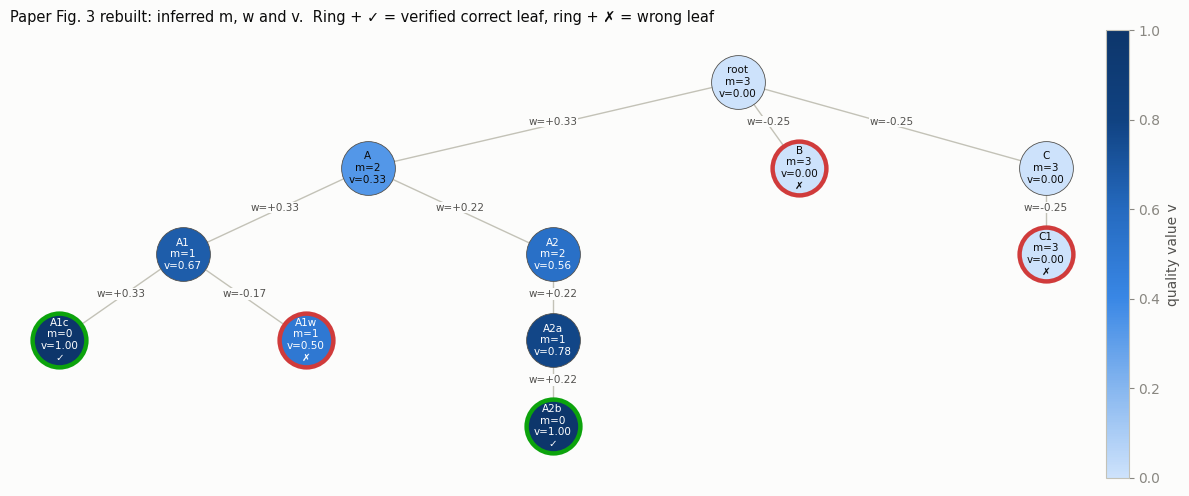

In [ ]:
#@title 1.3 · Plot style + draw a tree (colour = value v on a one-hue ramp, edge label = weighted reward w)
import matplotlib.pyplot as plt, matplotlib as mpl, numpy as np, os
from matplotlib.colors import LinearSegmentedColormap
FIG = "/kaggle/working/restmcts/figs"; os.makedirs(FIG, exist_ok=True)
# one palette for every chart in this notebook (validated categorical order; status colours only for right/wrong)
PAL = dict(blue="#2a78d6", orange="#eb6834", aqua="#1baf7a", yellow="#eda100", magenta="#e87ba4", violet="#4a3aa7",
           ink="#0b0b0b", ink2="#52514e", muted="#898781", grid="#e1e0d9", axis="#c3c2b7", surface="#fcfcfb",
           good="#0ca30c", bad="#d03b3b")
SEQ = LinearSegmentedColormap.from_list("v", ["#cde2fb", "#86b6ef", "#3987e5", "#256abf", "#104281", "#0d366b"])
mpl.rcParams.update({"figure.facecolor": PAL["surface"], "axes.facecolor": PAL["surface"], "axes.edgecolor": PAL["axis"],
    "axes.labelcolor": PAL["ink2"], "xtick.color": PAL["muted"], "ytick.color": PAL["muted"], "text.color": PAL["ink"],
    "axes.grid": True, "grid.color": PAL["grid"], "grid.linewidth": 0.6, "axes.spines.top": False,
    "axes.spines.right": False, "lines.linewidth": 2, "lines.markersize": 7, "font.size": 10, "legend.frameon": False})

def layout(root, keep=lambda x: True):
    pos, xs = {}, itertools.count()
    def rec(x):
        kids = [c for c in x.children if keep(c)]
        if not kids: pos[x] = (next(xs), -x.depth)
        else:
            for c in kids: rec(c)
            pos[x] = (np.mean([pos[c][0] for c in kids]), -x.depth)
    rec(root); return pos

def draw_tree(root, ax, value=lambda x: x.target_v, text=None, edge=None, keep=lambda x: True, title="",
              size=1500, fs=7.5):
    """Fill = v (light -> dark blue). Verified finished leaves get a status ring AND a check/cross mark."""
    pos = layout(root, keep)
    for x, (px, py) in pos.items():
        if x.parent is not None and x.parent in pos:
            qx, qy = pos[x.parent]; ax.plot([qx, px], [qy, py], color=PAL["axis"], lw=1, zorder=1)
            if edge and edge(x): ax.text((px+qx)/2, (py+qy)/2, edge(x), fontsize=fs, color=PAL["ink2"], ha="center",
                                         bbox=dict(fc=PAL["surface"], ec="none", pad=0.5), zorder=2)
    for x, (px, py) in pos.items():
        v = value(x); v = 0.5 if v is None else min(max(v, 0), 1)
        ring, lw, mark = PAL["ink2"], 0.6, ""
        if x.is_end and x.correct is not None:
            ring, lw, mark = (PAL["good"], 3.2, "✓") if x.correct else (PAL["bad"], 3.2, "✗")
        ax.scatter(px, py, s=size, c=[SEQ(v)], edgecolors=ring, linewidths=lw, zorder=3)
        label = (text(x) if text else "") + (f"\n{mark}" if mark and text else "")
        if label: ax.text(px, py, label, ha="center", va="center", fontsize=fs, zorder=4,
                          color="white" if v > 0.45 else PAL["ink"])
    ax.set_title(title, loc="left", fontsize=10.5); ax.axis("off")
    ax.set_ylim(min(p[1] for p in pos.values()) - 0.6, 0.6)

def v_colorbar(fig, ax):
    fig.colorbar(mpl.cm.ScalarMappable(cmap=SEQ), ax=ax, fraction=0.02, pad=0.01, label="quality value v")

fig, ax = plt.subplots(figsize=(12, 5))
draw_tree(fig3, ax, text=lambda x: f"{names[x].split('(')[0].strip()}\nm={x.min_steps-1}\nv={x.target_v:.2f}",
          edge=lambda x: f"w={x.target_w:+.2f}",
          title="Paper Fig. 3 rebuilt: inferred m, w and v.  Ring + ✓ = verified correct leaf, ring + ✗ = wrong leaf")
v_colorbar(fig, ax); plt.tight_layout(); fig.savefig(f"{FIG}/fig3_tree.png", dpi=120); plt.show()

---
# Part 2 · The policy $\pi$ as a step generator

MCTS\* never asks the policy for a whole solution. It asks for **one next step** given $(Q, s_1..s_k)$, many times, from many different nodes. This is $s_{k+1} \sim \pi(\cdot \mid Q, s_1,\dots,s_k)$ in the paper, and `get_next_step` in `MCTS/task.py`.

That workload has a special shape. **Every request from one tree shares a long prefix** (the system prompt, the question, and the earlier steps). So the policy runs behind a **vLLM server with prefix caching**. The KV cache for the shared prefix is computed once and reused by every sibling and descendant. Three T4-specific settings (all measured on this hardware earlier):

* `VLLM_ATTENTION_BACKEND=TRITON_ATTN`. FlashAttention-2 needs sm80 or newer and a T4 is sm75. Without this flag vLLM falls back to FlexAttention, which is about 5× slower.
* `--dtype half`. A T4 has fp16 tensor cores but no bf16 ones.
* `--generation-config vllm`. By default vLLM silently applies the model's `generation_config.json`. For Qwen that means top-p 0.8, top-k 20 and repetition penalty 1.05. This flag turns that off so every sampling parameter below is one we set on purpose.

**What counts as a step.** The official code prompts for `"Next step: ..."` and parses the reply with about 100 lines of string rules. I measured the "Step k:" format first (cell 2.4). On this 1.5B model it **costs 7 to 15 points of accuracy**, because the model writes less when it is forced into short numbered lines. So a step here is **one paragraph**: the prompt is Qwen's own math prompt, and generation stops at the next blank line (`stop=["\n\n"]`). The mechanism is the same (one step per call, with the steps so far as the prefix). This paragraph split is also the usual step definition for Qwen-family PRMs.

In [ ]:
#@title 2.1 · Launch / stop the vLLM policy server (separate process, own session -> safe to kill)
import time, signal, httpx, json
VENV_PY = "/kaggle/working/.vllm/bin/python"
BASE_MODEL = "Qwen/Qwen2.5-1.5B-Instruct"
sh(f"uv pip install --python {VENV_PY} wrapt -q")         # silences Kaggle's sitecustomize warning in the venv
_servers = {}

def start_policy_server(model=BASE_MODEL, gpu=0, port=8000, mem=0.90, tag="policy", max_len=4096):
    stop_policy_server(port)
    env = dict(os.environ, CUDA_VISIBLE_DEVICES=str(gpu), VLLM_ATTENTION_BACKEND="TRITON_ATTN",
               VLLM_LOGGING_LEVEL="WARNING")
    cmd = [VENV_PY, "-m", "vllm.entrypoints.openai.api_server", "--model", model, "--served-model-name", tag,
           "--dtype", "half", "--max-model-len", str(max_len), "--gpu-memory-utilization", str(mem),
           "--enable-prefix-caching", "--generation-config", "vllm", "--max-num-seqs", "256",
           "--port", str(port), "--disable-uvicorn-access-log", "--seed", "0"]
    log = open(f"{W}/logs/vllm_{port}.log", "w")
    p = subprocess.Popen(cmd, env=env, stdout=log, stderr=subprocess.STDOUT, start_new_session=True)
    _servers[port] = p
    deadline = time.time() + 600                                 # bounded wait, never an infinite loop
    while time.time() < deadline:
        if p.poll() is not None:
            raise RuntimeError("server died:\n" + sh(f"tail -30 {W}/logs/vllm_{port}.log"))
        try:
            if httpx.get(f"http://localhost:{port}/v1/models", timeout=2).status_code == 200:
                print(f"[{tag}] up on GPU{gpu}:{port} after {600-(deadline-time.time()):.0f}s  model={model}"); return p
        except Exception: pass
        time.sleep(3)
    raise TimeoutError("server did not come up in 600s")

def stop_policy_server(port=8000):
    p = _servers.pop(port, None)
    if p is not None and p.poll() is None:
        os.killpg(os.getpgid(p.pid), signal.SIGTERM)             # its OWN process group (start_new_session)
        try: p.wait(60)
        except Exception: os.killpg(os.getpgid(p.pid), signal.SIGKILL)
        time.sleep(3)

start_policy_server()
print(sh("nvidia-smi --query-gpu=index,memory.used --format=csv"))

[policy] up on GPU0:8000 after 98s  model=Qwen/Qwen2.5-1.5B-Instruct
index, memory.used [MiB]
0, 14263 MiB
1, 3 MiB


In [ ]:
#@title 2.1b · Optional 2nd policy replica on GPU 1 (only while GPU 1 is not training) - add_replica() / drop_replica()
def add_replica(model=BASE_MODEL, mem=0.45):
    start_policy_server(model=model, gpu=1, port=8001, mem=mem)
    if 8001 not in PORTS: PORTS.append(8001)
def drop_replica():
    if 8001 in PORTS: PORTS.remove(8001)
    time.sleep(5); stop_policy_server(8001); gc_cuda() if "gc_cuda" in globals() else None
add_replica(); print("PORTS", PORTS); print(sh("nvidia-smi --query-gpu=index,memory.used --format=csv"))

[policy] up on GPU1:8001 after 46s  model=Qwen/Qwen2.5-1.5B-Instruct
PORTS [8000, 8001]
index, memory.used [MiB]
0, 14263 MiB
1, 11949 MiB


In [ ]:
#@title 2.2 · Data (MATH train 7.5k, MATH-500 test) + answer checking
import logging; logging.getLogger("math_verify").setLevel(logging.ERROR)
from datasets import load_dataset
from math_verify import parse as mv_parse, verify as mv_verify

def last_boxed(s):
    """Content of the LAST \\boxed{...} (brace-matched), or None."""
    i = s.rfind("\\boxed")
    if i < 0: return None
    j = s.find("{", i)
    if j < 0: return None
    depth = 0
    for k in range(j, len(s)):
        depth += (s[k] == "{") - (s[k] == "}")
        if depth == 0: return s[j + 1:k]
    return None

def _norm(a):
    a = a.replace(" ", "").replace("\\!", "").replace("\\left", "").replace("\\right", "").replace("dfrac", "frac")
    a = a.replace("tfrac", "frac").replace("^\\circ", "").replace("^{\\circ}", "").replace("\\$", "").replace("$", "")
    return a.rstrip(".").strip()

def is_correct(pred_text, gt):
    """Paper verifies by string match (utils/verify_MATH.py). Here: fast normalized string match, then math_verify
    (symbolic equality, e.g. 0.5 == 1/2 == \\frac{1}{2}).  Timeouts off because this can run inside worker threads."""
    pb = last_boxed(pred_text or "")
    if pb is None: return False
    if _norm(pb) == _norm(gt): return True
    try:
        return bool(mv_verify(mv_parse("$" + gt + "$", parsing_timeout=None),
                              mv_parse("$" + pb + "$", parsing_timeout=None), timeout_seconds=None))
    except Exception:
        return False

_train = load_dataset("DigitalLearningGmbH/MATH-lighteval", split="train")
TRAIN = [dict(q=r["problem"], a=last_boxed(r["solution"]), level=r["level"], type=r["type"]) for r in _train]
TRAIN = [r for r in TRAIN if r["a"] is not None]
TEST = [dict(q=r["problem"], a=r["answer"], level=f"Level {r['level']}", type=r["subject"]) for r in
        load_dataset("HuggingFaceH4/MATH-500", split="test")]
print(len(TRAIN), "train problems with a boxed answer |", len(TEST), "MATH-500 test problems")
print("sanity:", is_correct("so \\boxed{\\dfrac{1}{2}}", "\\frac12"), is_correct("\\boxed{0.5}", "\\frac{1}{2}"),
      is_correct("\\boxed{3}", "4"), is_correct("no box", "4"))

Timeout is disabled as parsing_timeout is None or <= 0, you must provide                         the logic for timeout interuption yourself to prevent code getting stuck.
Timeout is disabled as timeout_seconds is None or <= 0, you must provide                         the logic for timeout interuption yourself to prevent code getting stuck.


7498 train problems with a boxed answer | 500 MATH-500 test problems
sanity: True True False False


In [ ]:
#@title 2.3 · The policy API: one step (= one paragraph) at a time, with token accounting (x-axis of paper Fig. 2)
from transformers import AutoTokenizer
tok = AutoTokenizer.from_pretrained(BASE_MODEL)
SYSTEM = "Please reason step by step, and put your final answer within \\boxed{}."   # Qwen's own math prompt
STEP_STOP = ["\n\n"]                                          # a step ends at a blank line (see 2.4 for why)
EOS_IDS = [tok.convert_tokens_to_ids("<|im_end|>"), tok.convert_tokens_to_ids("<|endoftext|>")]
CLIENT = httpx.Client(timeout=1800, limits=httpx.Limits(max_connections=1024, max_keepalive_connections=1024))
PORTS = [8000]      # policy replicas; a request is routed by its question so each tree stays on one prefix cache

def chat_prefix(q, advice=None):
    user = q if not advice else f"{q}\n\nAdvice for the next step: {advice}"
    return tok.apply_chat_template([{"role": "system", "content": SYSTEM}, {"role": "user", "content": user}],
                                   tokenize=False, add_generation_prompt=True)

class Budget:
    """Per-question token meter. Paper Fig. 2 plots accuracy vs. average COMPLETION tokens per question."""
    def __init__(self): self.completion = 0; self.prompt = 0; self.calls = 0
    def add(self, usage): self.completion += usage["completion_tokens"]; self.prompt += usage["prompt_tokens"]; self.calls += 1

def generate(prompts, n=1, max_tokens=256, temperature=0.7, top_p=1.0, stop=None, budget=None, port=None):
    port = port or PORTS[hash(prompts[0][:300]) % len(PORTS)]
    body = dict(model="policy", prompt=prompts, n=n, max_tokens=max_tokens, temperature=temperature, top_p=top_p,
                stop=stop or [], stop_token_ids=EOS_IDS)
    r = CLIENT.post(f"http://localhost:{port}/v1/completions", json=body); r.raise_for_status(); d = r.json()
    if budget is not None: budget.add(d["usage"])
    out = [[None] * n for _ in prompts]
    for ch in d["choices"]:
        i = ch["index"]; out[i // n][i % n] = (ch["text"], ch["finish_reason"], ch.get("stop_reason"))
    return out

def propose_steps(q, y, b, budget=None, temperature=0.7, advice=None, max_tokens=384):
    """s_{k+1} ~ pi(. | Q, s_1..s_k):  prompt = chat prefix + steps so far, stop at the next blank line.
    Returns de-duplicated [(step_text, is_end)]; is_end = a \\boxed answer appeared, or the model emitted EOS."""
    outs = generate([chat_prefix(q, advice) + y], n=b, max_tokens=max_tokens, temperature=temperature,
                    stop=STEP_STOP, budget=budget)[0]
    steps, seen = [], set()
    for text, fin, stop_reason in outs:
        t = text.strip("\n")
        if len(t.strip()) < 2 or t in seen: continue     # official: 'output too short' / duplicate child dropped
        seen.add(t)
        ended = ("\\boxed" in t) or (fin == "stop" and stop_reason in (None, *EOS_IDS))
        steps.append((t + "\n\n", ended))
    return steps

def cot_solve(q, n=1, temperature=0.0, budget=None, max_tokens=1024):
    """Plain chain-of-thought: a whole solution in one call (CoT / Self-Consistency / Best-of-N baselines)."""
    return [t for t, _, _ in generate([chat_prefix(q)], n=n, max_tokens=max_tokens, temperature=temperature,
                                      budget=budget)[0]]

if __name__ == "__main__" and "ex_demo_done" not in globals():   # demo once (re-running this cell only redefines)
    ex = TEST[3]
    print("PROMPT the policy sees:\n" + "-" * 60 + "\n" + chat_prefix(ex["q"]))
    bud = Budget()
    print("-" * 60 + "\nThree sampled FIRST steps (a b=3 expansion of the root):")
    for s, e in propose_steps(ex["q"], "", 3, bud): print("  >", repr(s[:140]), "| END" if e else "")
    sol = cot_solve(ex["q"], budget=bud)[0]
    print("-" * 60 + f"\nGreedy CoT solution:\n{sol}\n-> correct? {is_correct(sol, ex['a'])} (gold {ex['a']})")
    print(f"tokens: completion {bud.completion}, prompt {bud.prompt}, calls {bud.calls}"); ex_demo_done = True

PROMPT the policy sees:
------------------------------------------------------------
<|im_start|>system
Please reason step by step, and put your final answer within \boxed{}.<|im_end|>
<|im_start|>user
How many positive whole-number divisors does 196 have?<|im_end|>
<|im_start|>assistant

------------------------------------------------------------
Three sampled FIRST steps (a b=3 expansion of the root):
  > 'To determine how many positive whole-number divisors 196 has, we first need to find its prime factorization.\n\n' 
  > 'To determine the number of positive whole-number divisors of 196, we first need to find its prime factorization. We start by dividing 196 by' 
  > 'To find the number of positive whole-number divisors of \\(196\\), we first need to determine its prime factorization.\n\n' 
------------------------------------------------------------
Greedy CoT solution:
To determine the number of positive whole-number divisors of 196, we start by finding its prime factorization.



In [ ]:
#@title 2.4 · Prompt-format check: what is a "step"?  (greedy, 200 MATH-500 problems)
# Measured first (2026-09-25, same 200 problems, greedy):
#   Qwen standard prompt, free-form            59.0%   538 completion tok / solution
#   forced 'Step k:' lines, terse 1-shot        51.5%   344 tok   (7.0 steps)
#   forced 'Step k:' lines, detailed 1-shot     44.0%   366 tok   (7.1 steps)
# Forcing the paper's 'Step k:' format makes this 1.5B model write less and solve less. So a step here is
# a PARAGRAPH (text between blank lines). That is the usual PRM convention for Qwen models (Qwen2.5-Math-PRM,
# ProcessBench), and it leaves the model's natural format and accuracy untouched.
from concurrent.futures import ThreadPoolExecutor
import re
QWEN_STD = "Please reason step by step, and put your final answer within \\boxed{}."

def split_steps(text):
    """Solution text -> list of steps, each ending in '\\n\\n' (last one too), empty paragraphs dropped."""
    return [p.strip("\n") + "\n\n" for p in text.split("\n\n") if p.strip()]

sub = TEST[:200]
def one(ex):
    b = Budget(); t = generate([chat_prefix(ex["q"])], max_tokens=1024, temperature=0.0, budget=b)[0][0][0]
    return t, b.completion
t0 = time.time()
with ThreadPoolExecutor(128) as pool: res = list(pool.map(one, sub))
sols = [r[0] for r in res]; toks = [r[1] for r in res]; dt = time.time() - t0
nst = [len(split_steps(s)) for s in sols]
print(f"greedy acc {np.mean([is_correct(s, e['a']) for s, e in zip(sols, sub)]):.1%} | {np.mean(toks):.0f} tok/solution | "
      f"{sum(toks)/dt:.0f} tok/s")
print(f"paragraph-steps per solution: mean {np.mean(nst):.1f}, median {np.median(nst):.0f}, p90 {np.percentile(nst, 90):.0f}, max {max(nst)}")
print(f"tokens per step: {np.mean(toks)/np.mean(nst):.0f}")
print("\nexample, split into steps:")
for i, s in enumerate(split_steps(sols[3])): print(f"  [step {i+1}] {s.strip()[:150]!r}")

greedy acc 58.5% | 541 tok/solution | 1511 tok/s
paragraph-steps per solution: mean 9.6, median 8, p90 16, max 30
tokens per step: 57

example, split into steps:
  [step 1] 'To determine the number of positive whole-number divisors of 196, we start by finding its prime factorization.'
  [step 2] '1. **Prime Factorization of 196:**\n   - 196 is an even number, so it is divisible by 2.\n   - \\( 196 \\div 2 = 98 \\)\n   - 98 is also even, so it is divi'
  [step 3] 'Therefore, the prime factorization of 196 is:\n   \\[\n   196 = 2^2 \\times 7^2\n   \\]'
  [step 4] '2. **Using the Formula for Divisors:**\n   - If a number \\( n \\) has a prime factorization of \\( p_1^{e_1} \\times p_2^{e_2} \\times \\cdots \\times p_k^{e'
  [step 5] '3. **Applying the Formula:**\n   - For \\( 196 = 2^2 \\times 7^2 \\), we have:\n     \\[\n     (2 + 1)(2 + 1) = 3 \\times 3 = 9\n     \\]'
  [step 6] 'Thus, the number of positive whole-number divisors of 196 is \\(\\boxed{9}\\).'


---
# Part 3 · Initial value data $D_{V_0}$ and the value model $V_\theta$

Algorithm 1, lines 2–3: `D_V0 ← generate_value_data(D0, w, v)`, then `V0 ← train_value_model(V_θ, D_V0)`.

**For math, the paper builds $D_{V_0}$ like this (App. B.1):** *"we use Mistral-7B: MetaMATH as a policy to generate solution traces in a simple breadth-first-search (BFS) manner, obtaining a search tree … we verify the obtained answers of all leaf nodes … The verified search trees are then used to derive data samples with target values."* So the recipe is: build a tree, check the leaves against the answer, then run the same value inference as Part 1.2. No human looks at any step.

My BFS tree per question: branch **3** at step 1, branch **3** again at step 2, then finish each of the 9 frontier nodes with one sampled rollout. The rollout is split into paragraph-steps, so every step becomes its own tree node. That gives up to 9 verified leaves, with shared prefixes that let $m_k$ differ between branches.

**One subtlety.** A tree whose leaves are *all wrong* produces **no** samples (the official code returns `[]` when `flag` is false), because without one correct leaf nothing has a finite $m$. A tree whose leaves are *all right* produces only rising values. The informative trees are the mixed ones.

In [ ]:
#@title 3.1 · Build D_V0: BFS trees on 400 MATH-train problems -> verify leaves -> infer v  (runs in background)
import threading, traceback, pickle
JOBS = {}
def run_bg(name, fn, *a, **k):
    """Run fn(state, ...) in a daemon thread; poll JOBS[name]. (No prints from threads: they would land in
    whatever cell happens to be running.)"""
    st = dict(status="running", t0=time.time(), done=0, total=None, err=None, result=None, log=[])
    def wrap():
        try: st["result"] = fn(st, *a, **k); st["status"] = "done"
        except Exception: st["status"] = "error"; st["err"] = traceback.format_exc()
        st["t1"] = time.time()
    JOBS[name] = st; threading.Thread(target=wrap, daemon=True).start(); return st

def job(name):
    st = JOBS[name]; el = st.get("t1", time.time()) - st["t0"]
    print(f"[{name}] {st['status']} | {st['done']}/{st['total']} | {el/60:.1f} min")
    if st["err"]: print(st["err"][-2500:])
    return st

def parse_steps(outs):
    steps, seen = [], set()
    for text, fin, stop_reason in outs:
        t = text.strip("\n")
        if len(t.strip()) < 2 or t in seen: continue
        seen.add(t); steps.append((t + "\n\n", ("\\boxed" in t) or (fin == "stop" and stop_reason in (None, *EOS_IDS))))
    return steps

def propose_many(q, ys, b, budget=None, temperature=0.7, advice=None, max_tokens=384):
    """Expand several nodes of one tree in ONE request (vLLM batches them and shares the prefix cache)."""
    outs = generate([chat_prefix(q, advice) + y for y in ys], n=b, max_tokens=max_tokens, temperature=temperature,
                    stop=STEP_STOP, budget=budget)
    return [parse_steps(o) for o in outs]

def build_bfs_tree(ex, widths=(3, 3), temperature=0.7):
    budget, root = Budget(), TreeNode("")
    frontier = [root]
    for b in widths:                                    # BFS levels: branch b at every frontier node
        new = []
        for node, kids in zip(frontier, propose_many(ex["q"], [n.y for n in frontier], b, budget, temperature)):
            node.expanded = True
            for step, end in kids:
                c = node.add(step); c.is_end = end
                if not end: new.append(c)
        frontier = new
    if frontier:                                        # finish every frontier node with one sampled rollout
        outs = generate([chat_prefix(ex["q"]) + n.y for n in frontier], n=1, max_tokens=1024,
                        temperature=temperature, budget=budget)
        for node, o in zip(frontier, outs):
            text, fin, _ = o[0]; cur = node
            for s in split_steps(text): cur.expanded = True; cur = cur.add(s)
            if cur is not node and fin == "stop": cur.is_end = True   # length-capped chains stay unfinished -> pruned
    for x in root.walk():                               # VERIFY every finished leaf against the gold answer
        if x.is_end: x.correct = is_correct(x.y, ex["a"])
    samples = infer_tree_values(root)                   # Part 1.2, unchanged
    return root, samples, budget

def tree_to_paths(root):
    """Pack a verified tree into root->leaf paths for training. Every node with a target is assigned to exactly
    ONE path position, so the loss sees each (partial solution, v) pair exactly once, as in the official data."""
    paths, owned = [], set()
    for leaf in root.walk():
        if not leaf.is_end or leaf.min_steps >= INF_STEPS: continue
        chain = []; cur = leaf
        while cur.parent is not None: chain.append(cur); cur = cur.parent
        chain.reverse()
        targets = [None if (x.id in owned or x.target_v is None) else x.target_v for x in chain]
        owned.update(x.id for x in chain)
        if any(t is not None for t in targets): paths.append(dict(steps=[x.step for x in chain], targets=targets))
    return paths

rng = random.Random(1); _perm = rng.sample(range(len(TRAIN)), len(TRAIN))
D0_IDX, DG_IDX = _perm[:400], _perm[400:1000]         # value-init questions / self-training questions (disjoint)

def dv0_job(st, idx):
    st["total"] = len(idx); out = [None] * len(idx)
    def one(i):
        root, samples, b = build_bfs_tree(TRAIN[idx[i]])
        ends = [x for x in root.walk() if x.is_end]
        out[i] = dict(root=root, n_samples=len(samples), n_end=len(ends), n_ok=sum(bool(x.correct) for x in ends),
                      tok=b.completion, paths=tree_to_paths(root), q=TRAIN[idx[i]]["q"], a=TRAIN[idx[i]]["a"])
        st["done"] += 1
    with ThreadPoolExecutor(48) as pool: list(pool.map(one, range(len(idx))))
    pickle.dump([{k: v for k, v in r.items() if k != "root"} for r in out], open(f"{W}/dv0.pkl", "wb"))
    return out

run_bg("dv0", dv0_job, D0_IDX); time.sleep(60); job("dv0");

[dv0] running | 20/400 | 1.0 min


In [ ]:
#@title 3.1b · Poll D_V0 job + summarize the verified trees
st = job("dv0")
if st["status"] == "done":
    R = st["result"]
    ok_frac = np.array([r["n_ok"] / max(r["n_end"], 1) for r in R])
    mixed = sum(0 < r["n_ok"] < r["n_end"] for r in R); allok = sum(r["n_ok"] == r["n_end"] > 0 for r in R)
    none = sum(r["n_ok"] == 0 for r in R)
    V0_targets = [t for r in R for p in r["paths"] for t in p["targets"] if t is not None]
    print(f"trees: {len(R)} | finished leaves/tree {np.mean([r['n_end'] for r in R]):.1f} | leaf accuracy {ok_frac.mean():.1%}")
    print(f"mixed (some right, some wrong) {mixed} | all right {allok} | NO correct leaf (-> no samples) {none}")
    print(f"D_V0 samples (partial solution, v): {len(V0_targets):,} | paths: {sum(len(r['paths']) for r in R):,} | "
          f"completion tokens {sum(r['tok'] for r in R)/1e6:.2f}M")
    print("target v histogram:", np.histogram(V0_targets, bins=10, range=(0, 1))[0].tolist())

[dv0] done | 400/400 | 31.2 min
trees: 400 | finished leaves/tree 7.2 | leaf accuracy 53.3%
mixed (some right, some wrong) 193 | all right 108 | NO correct leaf (-> no samples) 99
D_V0 samples (partial solution, v): 18,155 | paths: 2,222 | completion tokens 1.71M
target v histogram: [5497, 781, 1226, 1244, 1237, 1812, 1306, 1354, 1556, 2142]


## 3.2 · The value model: exactly the official architecture

From the official `models/value_models.py`:

```python
class Mistral_VM(nn.Module):
    def __init__(self, base, vocab_size=32000):
        self.base_model = base
        self.LN = nn.Linear(vocab_size, 1)
    def forward(self, input_ids, attention_mask):
        outputs = self.base_model(input_ids=input_ids, attention_mask=attention_mask).logits[:, -1, :]
        value_outputs = self.LN(outputs)
        return value_outputs.squeeze(dim=1)
```

So $V_\theta(p\,|\,q) = \mathbf{w}^\top\,\text{logits}_{\text{last}} + b$. The input is the causal LM's **next-token logits at the last token** (a vector as long as the vocabulary: 151,936 numbers for Qwen), and a single linear layer maps it to a scalar. There is no sigmoid. Training uses plain MSE against the inferred $v$ (Eq. 37), and at use time the output is clipped to $[0,1]$.

**What this head really is.** The logits are $W_U h$, where $h$ is the final hidden state and $W_U$ is the unembedding matrix. So $\mathbf{w}^\top W_U h = (W_U^\top \mathbf{w})^\top h$. That is still a **linear probe on the final hidden state** $h$ (1,536 numbers). It is just parametrized through the vocabulary, with 152k parameters instead of 1.5k. We verify this numerically below.

It has one practical consequence. With Adam, every one of the 152k weights moves by about the learning rate on each early step. The output therefore moves by up to $\text{lr}\times\sum_i|\text{logit}_i|$. That sum is in the hundreds of thousands, so the head needs a *tiny* learning rate. We compute it from the data instead of guessing.

**Scoring every prefix in one pass.** The official code feeds each partial solution $p_k$ as its own sequence and reads position $-1$. Attention is causal, so the hidden state at the last token of $p_k$ is the same whether or not $s_{k+1},\dots$ come after it. One forward pass over a whole root-to-leaf path therefore gives $V_\theta(p_1),\dots,V_\theta(p_K)$ at once. You gather at the step-boundary positions. This is identical math and about $K\times$ fewer tokens, which matters on a T4. It is checked numerically below.

Backbone = `Qwen2.5-1.5B-Instruct`, the same model as the policy, which mirrors the paper's MetaMath-Mistral policy and value pair. It is fp16 with frozen weights plus LoRA (r = 16, all linear layers) and the fp32 vocab head. Input text uses the official format: `"Problem: " + q + "\nSolution:\n" + steps`.

Problem: A region is bounded by semicircular arcs constructed on the side of a square whose sides measure $2/\pi$, as shown. What is the perimeter of this region? [asy]
path a=(10,0)..(5,5)--(5,-5)..cycle;
path b=(0,10)..(5,5)--(-5,5)..cycle;
path c=(-10,0)..(-5,5)--(-5,-5)..cycle;
path d=(0,-10)..(-5,-5)--( 
Gold answer: 4 | leaves: 9 finished, 5 correct


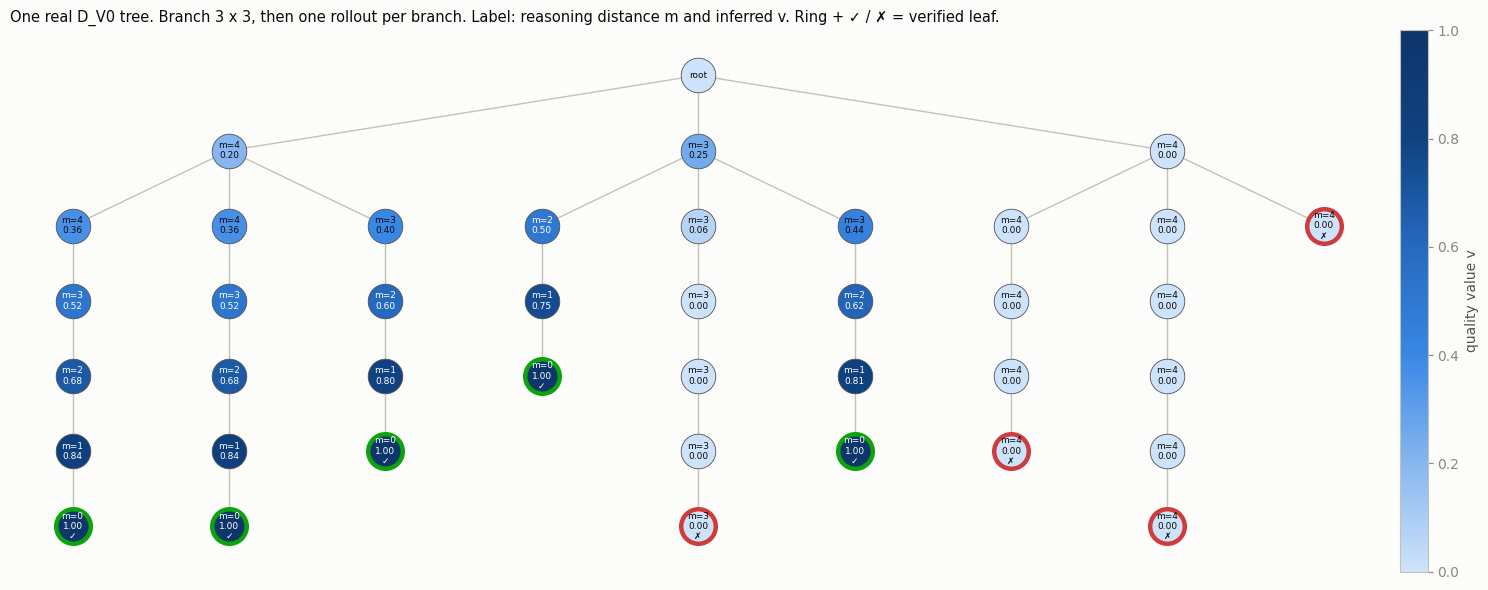


Split after depth 0 (parent v=0.00):
  he=1 m=4 w=+0.200 v=0.200 | 'To determine the perimeter of the region bounded by the semicircular arcs, we need to calculate the lengths of the semicircular arcs that form the boundary of the region. The side length of the square is \\( \\frac{2}{\\pi}'
  he=1 m=3 w=+0.250 v=0.250 | 'To find the perimeter of the region bounded by the semicircular arcs, we need to calculate the lengths of the arcs and add them together. Each semicircular arc has a diameter equal to the side length of the square, which'
  he=0 m=4 w=-0.200 v=0.000 | 'To determine the perimeter of the region bounded by the semicircular arcs, we first need to understand the configuration of the region. The region is composed of four semicircular arcs, each with a radius of \\( \\frac{2}{'


In [ ]:
#@title 3.1c · A real D_V0 tree: Qwen's BFS tree on a MATH-train problem, leaves verified, v inferred (no human)
cands = [r for r in JOBS["dv0"]["result"] if 0 < r["n_ok"] < r["n_end"] and 25 <= sum(1 for _ in r["root"].walk()) <= 45]
r = sorted(cands, key=lambda r: abs(r["n_ok"] / r["n_end"] - 0.5))[0]
kept = lambda x: x.min_steps < INF_STEPS                   # pruned = unfinished branches (never reached an answer)
print("Problem:", r["q"][:300], "\nGold answer:", r["a"], f"| leaves: {r['n_end']} finished, {r['n_ok']} correct")
fig, ax = plt.subplots(figsize=(15, 6))
draw_tree(r["root"], ax, keep=kept, size=620, fs=6.5,
          text=lambda x: "root" if x.parent is None else f"m={x.min_steps-1}\n{x.target_v:.2f}",
          title="One real D_V0 tree. Branch 3 x 3, then one rollout per branch. Label: reasoning distance m and "
                "inferred v. Ring + ✓ / ✗ = verified leaf.")
v_colorbar(fig, ax); plt.tight_layout(); fig.savefig(f"{FIG}/dv0_tree.png", dpi=120); plt.show()
# the two sibling steps where the tree splits into a right and a wrong future, with their inferred targets
for x in r["root"].walk():
    kids = [c for c in x.children if kept(c)]
    if len(kids) >= 2 and len({c.he for c in kids}) == 2:
        print(f"\nSplit after depth {x.depth} (parent v={x.target_v:.2f}):")
        for c in kids: print(f"  he={c.he} m={c.min_steps-1} w={c.target_w:+.3f} v={c.target_v:.3f} | {c.step.strip()[:220]!r}")
        break

In [ ]:
#@title 3.2 · ValueModel = Qwen backbone (+LoRA) -> last-token vocab logits -> Linear(151936, 1)   [GPU 1]
import torch, torch.nn as nn, torch.nn.functional as F
from transformers import AutoModelForCausalLM
from peft import LoraConfig, get_peft_model
VDEV = torch.device("cuda:1")

def vm_header(q): return "Problem: " + q + "\nSolution:\n"            # official prompt_answer format
_enc_cache = {}
def enc(text):
    ids = _enc_cache.get(text)
    if ids is None: ids = _enc_cache[text] = tok(text, add_special_tokens=False).input_ids
    return ids

def encode_path(q, steps, max_len=1536):
    """Piecewise tokenization: header, then each step. The boundary index of step k is the position whose
    logits give V(p_k). The same function is used in training and at search time, so they always agree."""
    ids = list(enc(vm_header(q))); bounds = []
    for s in steps:
        piece = enc(s)
        if len(ids) + len(piece) > max_len: break
        ids += piece; bounds.append(len(ids) - 1)
    return ids, bounds

class ValueModel(nn.Module):
    def __init__(self, base=BASE_MODEL, r=16):
        super().__init__()
        lm = AutoModelForCausalLM.from_pretrained(base, dtype=torch.float16).to(VDEV)
        lm.config.use_cache = False
        lm.gradient_checkpointing_enable(gradient_checkpointing_kwargs={"use_reentrant": False})
        self.lm = get_peft_model(lm, LoraConfig(r=r, lora_alpha=2 * r, lora_dropout=0.0,
                  target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"]))
        self.V = lm.config.vocab_size
        self.head = nn.Linear(self.V, 1).to(VDEV)                      # the official "LN": Linear(vocab, 1), fp32
        nn.init.zeros_(self.head.weight); nn.init.constant_(self.head.bias, 0.5)
    @property
    def causal_lm(self): return self.lm.get_base_model()             # Qwen2ForCausalLM (LoRA injected in place)

    def logits_at(self, input_ids, attn, pb, pt):
        """Next-token logits ONLY at the gathered positions (never materialise the (B, S, 151936) tensor)."""
        with torch.autocast("cuda", dtype=torch.float16):
            h = self.causal_lm.model(input_ids=input_ids, attention_mask=attn).last_hidden_state  # post final-norm
            return self.causal_lm.lm_head(h[pb, pt])                                            # (N, vocab) fp16

    def forward(self, input_ids, attn, pb, pt):
        logits = self.logits_at(input_ids, attn, pb, pt)
        with torch.autocast("cuda", enabled=False):                    # the 152k-wide dot product stays fp32
            return self.head(logits.float()).squeeze(-1)               # raw, unclipped (clip at use time)

def collate(batch):
    """batch = [(ids, bounds)] -> right-padded tensors + flat gather indices. Right padding is fine because we
    gather explicit positions (the official code reads position -1, which is why it needs left/max padding)."""
    L = max(len(ids) for ids, _ in batch)
    x = torch.full((len(batch), L), tok.pad_token_id, dtype=torch.long); m = torch.zeros_like(x)
    pb, pt = [], []
    for i, (ids, bounds) in enumerate(batch):
        x[i, :len(ids)] = torch.tensor(ids); m[i, :len(ids)] = 1
        pb += [i] * len(bounds); pt += bounds
    return x.to(VDEV), m.to(VDEV), torch.tensor(pb, device=VDEV), torch.tensor(pt, device=VDEV)

vm = ValueModel()
n_lora = sum(p.numel() for n, p in vm.named_parameters() if "lora_" in n)
print(f"backbone {sum(p.numel() for p in vm.lm.parameters() if not p.requires_grad)/1e9:.2f}B frozen fp16 | "
      f"LoRA {n_lora/1e6:.1f}M trainable | head Linear({vm.V}, 1) = {vm.head.weight.numel():,} weights")

q_demo = TEST[3]["q"]; st_demo = split_steps(sols[3])
with torch.no_grad():
    torch.nn.init.normal_(vm.head.weight, std=1e-3)                  # temporary random head just for the checks
    # ---- check 1: scoring K prefixes in ONE pass == scoring each prefix separately (causal attention) ----
    packed = vm(*collate([encode_path(q_demo, st_demo)]))
    single = torch.cat([vm(*collate([encode_path(q_demo, st_demo[:k])]))[-1:] for k in range(1, len(st_demo) + 1)])
    # ---- check 2: vocab head == linear probe on the hidden state:  w^T (W_U h) + b = (W_U^T w)^T h + b ----
    x, m_, pb, pt = collate([encode_path(q_demo, st_demo)])
    with torch.autocast("cuda", dtype=torch.float16):
        h = vm.causal_lm.model(input_ids=x, attention_mask=m_).last_hidden_state[pb, pt]
    W_U = vm.causal_lm.lm_head.weight.float()                         # (vocab, hidden) - tied to the embedding
    probe = W_U.T @ vm.head.weight.float().squeeze(0)                 # (hidden,) = W_U^T w  -> 1536 numbers
    via_probe = h.float() @ probe + vm.head.bias
    nn.init.zeros_(vm.head.weight)                                    # back to the real init (w = 0, b = 0.5)
print(f"{len(st_demo)} prefixes | packed-in-one-pass vs one-prefix-per-pass: max |diff| = {(packed - single).abs().max():.2e}")
print(f"vocab head vs hidden-state probe (W_U^T w): max |diff| = {(packed - via_probe).abs().max():.2e}  "
      f"(only fp16 rounding of the logits)  | probe has {probe.numel()} numbers")
print(f"GPU1 memory: {torch.cuda.memory_allocated(VDEV) / 2**30:.2f} GB")

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

backbone 1.54B frozen fp16 | LoRA 18.5M trainable | head Linear(151936, 1) = 151,936 weights
6 prefixes | packed-in-one-pass vs one-prefix-per-pass: max |diff| = 3.55e-03
vocab head vs hidden-state probe (W_U^T w): max |diff| = 2.87e-04  (only fp16 rounding of the logits)  | probe has 1536 numbers
GPU1 memory: 3.82 GB


## 3.3 · Training $V_0$ on $D_{V_0}$ (Eq. 37) and measuring it (Eq. 38)

$$\mathcal{L}_{MSE} = \mathbb{E}_{(q,p,v)\sim D_{V_0}}\,\bigl|V_\theta(p\,|\,q) - v\bigr|^2 \qquad\qquad \text{Acc} = \tfrac{1}{t}\textstyle\sum_i \mathbb{1}\bigl[\,|\text{clip}(V_\theta(p_i|q_i),0,1) - v_i^*| < 0.1\,\bigr]$$

The paper's initial value model reaches **69.3%** on this ±0.1 accuracy, measured on its own held-out split of about 473k science samples.

Two things are added here so the number cannot fool us:
* **The split is by question, not by sample.** Prefixes of the same tree are near-duplicates, so a per-sample split would leak.
* **Two trivial baselines.** The first predicts the training mean for every sample. The second predicts the mean target *at that step depth*. Depth alone already carries a lot of $v$, because $v_k = k/K$ on a clean path. The value model only earns credit for what it adds beyond these.
* **Leaf AUROC.** Take finished leaves only. The target is exactly 1 for a correct leaf and below 1 for a wrong one. Can $V_\theta$ rank correct answers above wrong ones? This is the ORM-like ability the search needs at the end.

In [ ]:
#@title 3.3 · train_value(): MSE on packed paths, LoRA + vocab head, head LR derived from the logit scale
from sklearn.metrics import roc_auc_score

def make_items(records):
    """records: [{q, paths:[{steps, targets}]}] -> dict items with ids, gather positions, targets, depths."""
    items = []
    for r in records:
        for p in r["paths"]:
            ids, bounds = encode_path(r["q"], p["steps"])
            keep = [(b, t, k + 1) for k, (b, t) in enumerate(zip(bounds, p["targets"])) if t is not None]
            if keep:
                items.append(dict(ids=ids, pos=[b for b, _, _ in keep], y=[t for _, t, _ in keep],
                                  depth=[d for _, _, d in keep], q=r["q"],
                                  leaf=len(bounds) == len(p["steps"]) and p["targets"][-1] is not None))
    return items

def batches(items, tok_budget, shuffle, seed=0):
    order = sorted(range(len(items)), key=lambda i: len(items[i]["ids"]))   # length-sorted -> little padding
    chunks, cur, L = [], [], 0
    for i in order:
        L2 = max(L, len(items[i]["ids"]))
        if cur and L2 * (len(cur) + 1) > tok_budget: chunks.append(cur); cur, L2 = [], len(items[i]["ids"])
        cur.append(i); L = L2
    if cur: chunks.append(cur)
    if shuffle: random.Random(seed).shuffle(chunks)
    return chunks

def batch_tensors(items, ch):
    return collate([(items[i]["ids"], items[i]["pos"]) for i in ch])

@torch.no_grad()
def predict_items(vm, items, tok_budget=24000):
    vm.eval(); preds = [None] * len(items)
    for ch in batches(items, tok_budget, shuffle=False):
        out = vm(*batch_tensors(items, ch)).float().cpu().numpy(); o = 0
        for i in ch: preds[i] = out[o:o + len(items[i]["pos"])]; o += len(items[i]["pos"])
    return preds

def depth_baseline(items):
    """Mean target per step depth (fit on TRAIN items) + global mean: the 'no model' predictors."""
    by = {}
    for it in items:
        for d, t in zip(it["depth"], it["y"]): by.setdefault(d, []).append(t)
    return {d: float(np.mean(v)) for d, v in by.items()}, float(np.mean([t for it in items for t in it["y"]]))

def evaluate_value(vm, items, base=None, tag=""):
    preds = predict_items(vm, items)
    P = np.concatenate(preds); T = np.concatenate([it["y"] for it in items]); D = np.concatenate([it["depth"] for it in items])
    res = dict(n=len(T), mse=float(np.mean((P - T) ** 2)), acc=float(np.mean(np.abs(np.clip(P, 0, 1) - T) < 0.1)))
    if base is not None:
        dm, mv = base
        res["acc_const"] = float(np.mean(np.abs(mv - T) < 0.1))
        res["acc_depth"] = float(np.mean(np.abs(np.array([dm.get(int(d), mv) for d in D]) - T) < 0.1))
    L = [(it["y"][-1] == 1.0, p[-1]) for it, p in zip(items, preds) if it["leaf"]]     # finished leaves only
    if len({l for l, _ in L}) == 2: res["leaf_auroc"] = float(roc_auc_score([l for l, _ in L], [p for _, p in L]))
    print(f"[{tag}] " + " | ".join(f"{k} {v:.3f}" if isinstance(v, float) else f"{k} {v}" for k, v in res.items()))
    return res

def train_value(vm, train_items, val_items, epochs=2, lr_lora=1e-4, head_move=0.02, tok_budget=6144, st=None, base=None):
    lora = [p for n, p in vm.named_parameters() if "lora_" in n and p.requires_grad]
    # Head LR from data: Adam moves every weight by ~lr on early steps, so the output moves <= lr * sum_i |logit_i|.
    x, m_, pb, pt = batch_tensors(train_items, list(range(8)))
    with torch.no_grad(): S = vm.logits_at(x, m_, pb, pt).float().abs().sum(-1).mean().item()
    lr_head = head_move / S
    opt = torch.optim.AdamW([{"params": lora, "lr": lr_lora, "weight_decay": 0.0},
                             {"params": vm.head.parameters(), "lr": lr_head, "weight_decay": 0.0}])
    base_lrs, scaler = [lr_lora, lr_head], torch.amp.GradScaler()
    total = epochs * len(batches(train_items, tok_budget, False)); step = 0
    hist = dict(step=[], loss=[], val=[], S=S, lr_head=lr_head)
    if st is not None: st["total"] = total
    for ep in range(epochs):
        vm.train()
        for ch in batches(train_items, tok_budget, True, seed=ep):
            mult = min(1.0, (step + 1) / 20) * 0.5 * (1 + math.cos(math.pi * step / total))     # warmup + cosine
            for g, b in zip(opt.param_groups, base_lrs): g["lr"] = b * mult
            y = torch.tensor([t for i in ch for t in train_items[i]["y"]], device=VDEV, dtype=torch.float32)
            loss = F.mse_loss(vm(*batch_tensors(train_items, ch)), y)                     # Eq. 37
            opt.zero_grad(set_to_none=True); scaler.scale(loss).backward(); scaler.unscale_(opt)
            torch.nn.utils.clip_grad_norm_(lora, 1.0)          # clip LoRA only; head grads are ~|logits|-sized by design
            scaler.step(opt); scaler.update(); step += 1
            hist["step"].append(step); hist["loss"].append(loss.item())
            if st is not None: st["done"] = step; st["loss"] = float(np.mean(hist["loss"][-25:]))
        if val_items: hist["val"].append(evaluate_value(vm, val_items, base, tag=f"epoch {ep+1}"))
    vm.eval(); return hist
print("defined: make_items / train_value / evaluate_value / depth_baseline")

defined: make_items / train_value / evaluate_value / depth_baseline


In [ ]:
#@title 3.4 · ValueService: many search threads -> one batched GPU forward (thread-safe, cached)
import queue
class ValueService:
    """MCTS* runs one thread per question. Each thread asks for V(p) of a few nodes at a time; this service
    collects requests from all threads for a few ms and scores them in ONE padded forward pass on GPU 1."""
    def __init__(self, vm, tok_budget=32000, wait=0.01):
        self.vm, self.tok_budget, self.wait = vm, tok_budget, wait
        self.q = queue.Queue(); self.n_forward = 0; self.n_scored = 0; self.alive = True
        threading.Thread(target=self._loop, daemon=True).start()

    def score(self, q, step_lists, all_positions=False):
        """step_lists: list of [s_1..s_k]. Returns V(p_k) clipped to [0,1] (or every prefix if all_positions)."""
        items = [encode_path(q, s) for s in step_lists]
        items = [(ids, b if all_positions else b[-1:]) for ids, b in items]
        slot = dict(ev=threading.Event()); self.q.put((items, slot))
        if not slot["ev"].wait(900): raise TimeoutError("value service stalled")
        if "err" in slot: raise RuntimeError(slot["err"])
        out = slot["v"]; return out if all_positions else [v[-1] if len(v) else 0.0 for v in out]

    @torch.no_grad()
    def _loop(self):
        while self.alive:
            reqs = [self.q.get()]; time.sleep(self.wait)
            while not self.q.empty(): reqs.append(self.q.get_nowait())
            flat = [(r, j, it) for r, (items, _) in enumerate(reqs) for j, it in enumerate(items)]
            res = {(r, j): [] for r, j, _ in flat}
            try:
                self.vm.eval(); order = sorted(flat, key=lambda f: len(f[2][0])); ch = []; L = 0
                def run(ch):
                    x = [it for _, _, it in ch if it[1]]
                    if x:
                        out = np.clip(self.vm(*collate(x)).float().cpu().numpy(), 0, 1); o = 0; self.n_forward += 1
                        for r, j, it in ch:
                            if it[1]: res[(r, j)] = out[o:o + len(it[1])].tolist(); o += len(it[1])
                for f in order:
                    L2 = max(L, len(f[2][0]))
                    if ch and L2 * (len(ch) + 1) > self.tok_budget: run(ch); ch, L2 = [], len(f[2][0])
                    ch.append(f); L = L2
                if ch: run(ch)
                self.n_scored += len(flat)
                for r, (items, slot) in enumerate(reqs): slot["v"] = [res[(r, j)] for j in range(len(items))]; slot["ev"].set()
            except Exception:
                err = traceback.format_exc()
                for _, slot in reqs: slot["err"] = err; slot["ev"].set()
print("ValueService defined")

ValueService defined


---
# Part 4 · MCTS\*: the search (App. C.1, Algorithm 2, official `MCTS/mcts.py`)

Each iteration has four stages. Every node $C$ stores $(p_C, n_C, v_C)$.

| Stage | Paper | What the code does |
|---|---|---|
| **Node selection** | Eq. 33: $\text{UCB}(C)=v_C+\epsilon\sqrt{\ln n_{parent}/n_C}$ | From the root, keep taking the child with the highest UCB until you reach a leaf. An unvisited child scores $v_C + \text{INF}$, so each child is tried once before any is revisited. If the leaf has $v_C \ge l = 0.9$, **stop and return it**. |
| **Self-critic** | Alg. 2 line 13 | Ask the policy whether the solution is already finished. A `\boxed{}` answer counts as finished without asking (official code). Otherwise *simple* mode asks "solved or unsolved?" (official default), and *common* mode asks for **advice**, which is then pasted into the expansion prompt (paper App. F). |
| **Thought expansion** | lines 15–19 | Sample $b=3$ next steps. Each new child gets $v \leftarrow V_\theta(p_C\,|\,q)$. |
| **Greedy MC rollout** | lines 20–28, Eq. 34 | From the best new child, simulate $m$ more steps. At each step sample $d$ candidates, keep the highest-valued one, and remember the best value $v_{max}$ seen. Then $v_{C'} \leftarrow \alpha v_{C'} + (1-\alpha) v_{max}$ and $n_{C'} \mathrel{+}= 1$. The simulated steps are **not** added to the tree. They only improve the value estimate. |
| **Backprop** | Eq. 35–36 | Walk up to the root. Each node does $n_C \mathrel{+}= 1$ and sets $v_C \leftarrow \sum_i n_{C_i} v_{C_i} / \sum_i n_{C_i}$, a visit-weighted average of its children. |

**Why rollouts matter here.** Other LLM-MCTS variants (TS-LLM, RAP) drop the simulation stage. The paper keeps it on purpose: *"a simulation process still brings about useful information for value estimation."*

**Settings (paper App. E.2):** $T=50$ iterations, $b=3$, $m=2$, $\alpha=0.5$, $l=0.9$, self-critic on. The exploration constant is $\epsilon\approx0.71$, which equals the official $c=0.5$ inside `sqrt(2 ln N / n)`, and INF $=1$. The official data-generation script uses $d=1$ (`roll_branch`).

**The final answer** is the node that crossed $l$. If none did within $T$ iterations, it is the highest-value *finished* leaf. If the chosen node has no final answer yet, the policy finishes it greedily. That extra call plays the role of the official `get_MATH_summary`, and its tokens are counted.

In [ ]:
#@title 3.5b · Poll V0 training (loss, progress)
st = job("trainV0"); print("recent train MSE", round(st.get("loss", float("nan")), 4))
if st["status"] == "done": H0 = st["result"]; print("head lr (derived) =", f"{H0['lr_head']:.2e}", "| sum|logits| =", f"{H0['S']:.3g}")

[trainV0] running | 173/376 | 12.3 min
recent train MSE 0.0868


In [ ]:
#@title ⏳ wait helper: sleep up to `sec` seconds or until the named jobs are done (bounded, never infinite)
def wait_jobs(names, sec=600, every=15):
    t_end = time.time() + sec
    while time.time() < t_end and any(JOBS[n]["status"] == "running" for n in names if n in JOBS): time.sleep(every)
    for n in names:
        if n in JOBS: job(n)
wait_jobs(["trainV0", "restem1"], sec=900)

[epoch 1] n 1671 | mse 0.073 | acc 0.350 | acc_const 0.149 | acc_depth 0.230 | leaf_auroc 0.884
[trainV0] running | 376/376 | 27.6 min
[restem1] done | 300/300 | 15.1 min


[V0 held-out] n 1671 | mse 0.068 | acc 0.377 | acc_const 0.149 | acc_depth 0.230 | leaf_auroc 0.883


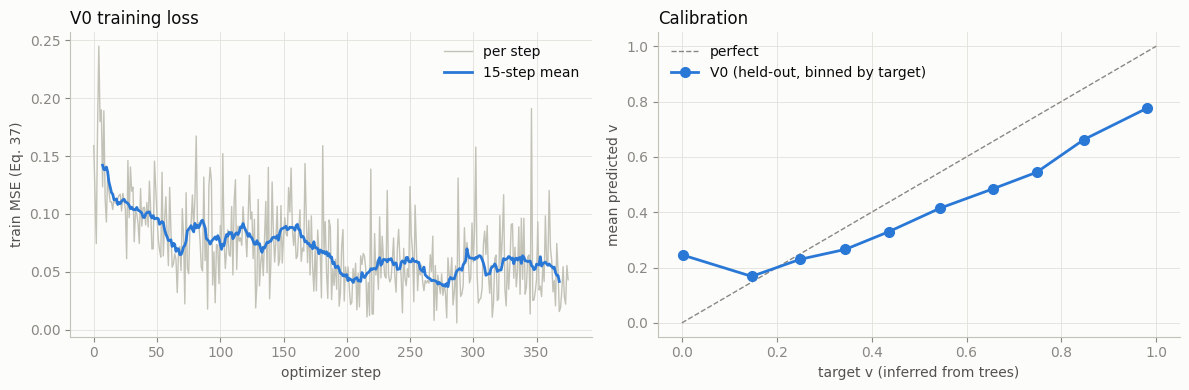

Eq. 38 accuracy (|clip(V)-v| < 0.1): V0 37.7% | constant 14.9% | depth-only 23.0% | paper's initial VM: 69.3% (on its own 473k-sample data)


In [ ]:
#@title 3.6 · V0 results: loss curve, Eq. 38 accuracy vs the trivial baselines, calibration
H0 = JOBS["trainV0"]["result"]
RES_V0 = evaluate_value(vm, va_items, BASE0, tag="V0 held-out")
torch.save({k: v for k, v in vm.state_dict().items() if "lora_" in k or k.startswith("head.")}, f"{W}/V0.pt")
P = np.concatenate(predict_items(vm, va_items)); T = np.concatenate([it["y"] for it in va_items])
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4))
sm = np.convolve(H0["loss"], np.ones(15) / 15, mode="valid")
a1.plot(H0["loss"], color=PAL["axis"], lw=1, label="per step"); a1.plot(range(7, 7 + len(sm)), sm, color=PAL["blue"], label="15-step mean")
a1.set_xlabel("optimizer step"); a1.set_ylabel("train MSE (Eq. 37)"); a1.set_title("V0 training loss", loc="left"); a1.legend()
bins = np.linspace(0, 1, 11); idx = np.clip(np.digitize(T, bins) - 1, 0, 9)
mt = [T[idx == b].mean() for b in range(10) if (idx == b).any()]; mp = [np.clip(P, 0, 1)[idx == b].mean() for b in range(10) if (idx == b).any()]
a2.plot([0, 1], [0, 1], color=PAL["muted"], lw=1, ls="--", label="perfect")
a2.plot(mt, mp, marker="o", color=PAL["blue"], label="V0 (held-out, binned by target)")
a2.set_xlabel("target v (inferred from trees)"); a2.set_ylabel("mean predicted v"); a2.set_title("Calibration", loc="left"); a2.legend()
plt.tight_layout(); fig.savefig(f"{FIG}/v0_train.png", dpi=120); plt.show()
print(f"Eq. 38 accuracy (|clip(V)-v| < 0.1): V0 {RES_V0['acc']:.1%} | constant {RES_V0['acc_const']:.1%} | "
      f"depth-only {RES_V0['acc_depth']:.1%} | paper's initial VM: 69.3% (on its own 473k-sample data)")

**Reading the V0 numbers**

* **±0.1 accuracy (Eq. 38) is 37.7%** on held-out *questions*. A constant predictor gets 14.9% and depth alone gets 23.0%. So V0 has learned about 15 points beyond "how far into the solution are we". The paper's 69.3% comes from 473k samples, most of them on reference-solution paths where $v_k = k/K$ exactly. Here there are 16k samples, all from the model's own messy trees.
* **Leaf AUROC is 0.883.** Take a finished solution the model wrote. V0 ranks a correct one above a wrong one 88% of the time, and no human ever labeled a step to get there. This is the property the search and Best-of-N rely on.
* **Calibration is squashed toward the middle.** A truly correct finished solution (target 1.0) gets about 0.78 on average. MSE training on noisy targets does this: when unsure, predict near the mean. **Consequence for MCTS\*:** the early-stop rule "$v \ge l = 0.9$" will rarely fire with V0, so most searches will spend their full $T$ budget. Keep this in mind when reading the token counts in Part 5.

In [ ]:
#@title 3.5 · Train V0 on D_V0 (90/10 split BY QUESTION) - background thread, poll below
if 8001 in PORTS: drop_replica()                                   # GPU 1 goes back to the value model
R0 = JOBS["dv0"]["result"]
qs = [r["q"] for r in R0]; val_q = set(random.Random(3).sample(qs, len(qs) // 10))
tr_items = make_items([r for r in R0 if r["q"] not in val_q]); va_items = make_items([r for r in R0 if r["q"] in val_q])
BASE0 = depth_baseline(tr_items)
print(f"train paths {len(tr_items)} ({sum(len(i['y']) for i in tr_items):,} targets, "
      f"{sum(len(i['ids']) for i in tr_items)/1e6:.2f}M tokens) | val paths {len(va_items)} "
      f"({sum(len(i['y']) for i in va_items):,} targets)")
print(f"tokens if every prefix were its own sequence (official style): "
      f"{sum(p + 1 for it in tr_items for p in it['pos'])/1e6:.2f}M  <- what packing saves")
evaluate_value(vm, va_items, BASE0, tag="V before training (w=0, b=0.5)")
if "trainV0" not in JOBS:
    run_bg("trainV0", lambda st: train_value(vm, tr_items, va_items, epochs=2, st=st, base=BASE0))
time.sleep(45); st = job("trainV0"); print("recent loss", st.get("loss"))

train paths 2005 (16,480 targets, 1.08M tokens) | val paths 217 (1,671 targets)
tokens if every prefix were its own sequence (official style): 6.44M  <- what packing saves
[V before training (w=0, b=0.5)] n 1671 | mse 0.142 | acc 0.152 | acc_const 0.149 | acc_depth 0.230 | leaf_auroc 0.500
[trainV0] running | 10/376 | 0.8 min
recent loss 0.15642158612608908


In [ ]:
#@title 4.1 · class MCTSStar  (Algorithm 2)
from dataclasses import dataclass, asdict

CRITIC_SIMPLE = ('Given a science problem and some corresponding steps, if the given steps have already solved the problem '
                 'and provided the final answer to the question, then you should output: "solved". Otherwise, please '
                 'output: "unsolved".\nFollowing the instruction, output "unsolved" or "solved", with no other '
                 'information.\n\nProblem: ')                                   # official single_reflection_prompt_simple_mistral
CRITIC_COMMON = ('Given a science or math problem and a corresponding solution that may be incomplete, your task is to '
                 'judge whether the solution has already reached a final answer or conclusion for the problem. If the '
                 'solution has already reached a final answer or conclusion, you should directly output "Final answer '
                 'reached". Otherwise, you should give some advice on how to solve the problem based on current steps or '
                 'what to consider next.\n\nProblem: ')                          # paper App. F self-critic instruction

@dataclass
class MCTSConfig:
    iters: int = 50          # T
    branch: int = 3          # b
    roll_steps: int = 2      # m
    roll_branch: int = 1     # d
    alpha: float = 0.5       # Eq. 34
    eps: float = 0.71        # Eq. 33 exploration constant (= official c=0.5 inside sqrt(2 ln N / n))
    inf: float = 1.0         # bonus of an unvisited child (official INF)
    end_gate: float = 0.9    # l
    critic: str = "simple"   # 'simple' | 'common' | 'none'
    temperature: float = 0.7
    full: bool = False       # official sample_value='full': data-generation mode, never stops early

def finish_greedy(q, y, budget):
    """Let the policy complete a partial solution (plays the role of the official get_MATH_summary call)."""
    return generate([chat_prefix(q) + y], max_tokens=1024, temperature=0.0, budget=budget)[0][0][0]

class MCTSStar:
    def __init__(self, ex, cfg, vs):
        self.q, self.gold, self.cfg, self.vs = ex["q"], ex.get("a"), cfg, vs
        self.root = TreeNode(""); self.budget = Budget(); self.count = 0
        self.finish, self.final, self.trace, self.n_critic_end = None, None, [], 0

    # ---------- helpers ----------
    def steps_of(self, node):
        s, cur = [], node
        while cur.parent is not None: s.append(cur.step); cur = cur.parent
        return s[::-1]

    def critic(self, y, depth, ended):
        """Self-critic -> '<end>' | '<continue>' | advice text (official get_simple_reflection / get_reflection)."""
        if depth == 0: return "<continue>"
        if ended or "\\boxed" in y[-600:]: return "<end>"
        if self.cfg.critic == "none": return "<continue>"
        simple = self.cfg.critic == "simple"
        content = (CRITIC_SIMPLE if simple else CRITIC_COMMON) + self.q + ("\nExisting Steps:\n" if simple else "\nSolution:\n") \
                  + y + ("\nOutput:" if simple else "")
        prompt = tok.apply_chat_template([{"role": "user", "content": content}], tokenize=False, add_generation_prompt=True)
        out = generate([prompt], max_tokens=4 if simple else 160, temperature=0.0, budget=self.budget)[0][0][0]
        if simple:
            end = "solved" in out.lower() and "unsolved" not in out.lower()
        else:
            end = "final answer reached" in out.lower()
        if end: self.n_critic_end += 1; return "<end>"
        return "<continue>" if simple else out.split("Advice:")[-1].strip()[:400]

    def ucb(self, parent, c):                                                     # Eq. 33
        if c.n == 0: return c.V + self.cfg.inf
        return c.V + self.cfg.eps * math.sqrt(math.log(parent.n) / c.n)

    def best_child(self, node):
        s = [self.ucb(node, c) for c in node.children]; top = max(s)
        return random.choice([c for c, v in zip(node.children, s) if v == top])

    # ---------- the four stages ----------
    def select(self):                                                             # Alg. 2 lines 4-8
        node = self.root
        while node.expanded and node.children: node = self.best_child(node)
        return node

    def expand(self, node):                                                       # lines 12-19
        if not node.reflection: node.reflection = self.critic(node.y, node.depth, node.is_end)
        if node.reflection == "<end>": return
        advice = None if node.reflection == "<continue>" else node.reflection    # 'common' critic -> advice o
        kids = propose_steps(self.q, node.y, self.cfg.branch, self.budget, self.cfg.temperature, advice)
        if not kids: node.reflection = "<end>"; return
        new = []
        for step, ended in kids:
            c = node.add(step); c.is_end = ended; self.count += 1; c.order = self.count
            if ended: c.reflection = "<end>"
            new.append(c)
        for c, v in zip(new, self.vs.score(self.q, [self.steps_of(c) for c in new])): c.V = v   # v_C <- V_theta(p_C|q)
        if self.cfg.full:                                                         # official: reflect every child in 'full' mode
            for c in new:
                if not c.reflection: c.reflection = self.critic(c.y, c.depth, c.is_end)
        node.expanded = True

    def rollout(self, node):                                                      # lines 20-28 (official greedyPolicy)
        roll = self.best_child(node)                                              # unvisited children: argmax v
        if not roll.reflection: roll.reflection = self.critic(roll.y, roll.depth, roll.is_end)
        if roll.reflection == "<end>":
            v_max = roll.V
        else:
            v_max, steps, y = 0.0, self.steps_of(roll), roll.y
            for _ in range(self.cfg.roll_steps):                                  # m simulated steps
                cands = propose_steps(self.q, y, self.cfg.roll_branch, self.budget, self.cfg.temperature)
                if not cands: break
                vals = self.vs.score(self.q, [steps + [s] for s, _ in cands])
                j = int(np.argmax(vals)); s, ended = cands[j]                     # keep only the most valuable path
                steps, y, v_max = steps + [s], y + s, max(v_max, vals[j])
                if self.critic(y, len(steps), ended) == "<end>": break
        roll.V = self.cfg.alpha * roll.V + (1 - self.cfg.alpha) * v_max          # Eq. 34
        roll.n += 1

    def backprop(self, node):                                                     # line 31, Eq. 35-36
        while node is not None:
            node.n += 1
            if node.expanded and node.children:
                tot = sum(c.n for c in node.children)
                if tot > 0: node.V = sum(c.V * c.n for c in node.children) / tot
            node = node.parent

    def run(self):
        for t in range(self.cfg.iters):
            node = self.select()
            if node is not self.root and node.V >= self.cfg.end_gate:            # lines 9-11
                if not self.cfg.full: self.finish, self.final = t + 1, node; break
                node.reflection = "<end>"                                         # 'full' mode: mark, keep searching
            self.expand(node)
            if node.expanded and node.children and node.reflection != "<end>": self.rollout(node)
            self.backprop(node)
            self.trace.append(dict(t=t + 1, tok=self.budget.completion, nodes=self.count, sel=node.id))
        return self

    # ---------- outputs ----------
    def answer(self):
        """Eval mode: final solution text (node that crossed l, else best finished leaf, else best node)."""
        node = self.final
        if node is None:
            ends = [x for x in self.root.walk() if x.is_end]
            cand = ends or [x for x in self.root.walk() if x is not self.root]
            node = max(cand, key=lambda x: x.V) if cand else self.root
        self.final = node
        return node.y if node.is_end else node.y + finish_greedy(self.q, node.y, self.budget)

    def harvest(self):
        """Data mode (Fig. 4): prune -> verify -> infer values.  Nodes the critic ended without a boxed answer are
        completed greedily first (official: summary call), so every kept leaf has a checkable final answer."""
        for x in list(self.root.walk()):
            if x.reflection == "<end>" and not x.is_end and not x.expanded and x is not self.root:
                cur = x
                for s in split_steps(finish_greedy(self.q, x.y, self.budget)): cur.expanded = True; cur = cur.add(s)
                if cur is not x: cur.is_end = True
        ends = [x for x in self.root.walk() if x.is_end]
        for x in ends: x.correct = is_correct(x.y, self.gold)                       # VERIFY (string/symbolic match)
        policy = [dict(q=self.q, text=x.y, correct=bool(x.correct)) for x in ends]  # candidate SFT traces
        samples = infer_tree_values(self.root)                                     # Part 1.2 value inference
        return policy, samples, tree_to_paths(self.root)
print("MCTSStar ready:", MCTSConfig())

MCTSStar ready: MCTSConfig(iters=50, branch=3, roll_steps=2, roll_branch=1, alpha=0.5, eps=0.71, inf=1.0, end_gate=0.9, critic='simple', temperature=0.7, full=False)


In [ ]:
#@title 4.2 · Watch one MCTS* search: iteration log + the tree it grew
VS = globals().get("VS") or ValueService(vm)

def show_search(ex, cfg, seed=0, title="", draw=True, fname=None):
    random.seed(seed)
    m = MCTSStar(ex, cfg, VS).run(); text = m.answer(); ok = is_correct(text, ex["a"])
    for x in m.root.walk():                                          # verify every finished leaf, for the picture only
        if x.is_end: x.correct = is_correct(x.y, ex["a"])
    print(f"iterations {len(m.trace)} | stopped at v>=l: {m.finish is not None} | nodes {m.count} | critic-ended "
          f"{m.n_critic_end} | completion tokens {m.budget.completion} | LLM calls {m.budget.calls}")
    print(f"final node: depth {m.final.depth}, v={m.final.V:.3f}, n={m.final.n} -> answer {last_boxed(text)!r} "
          f"(gold {ex['a']!r}) {'CORRECT' if ok else 'WRONG'}")
    if draw:
        path, cur = [], m.final
        while cur is not None: path.append(cur); cur = cur.parent
        fig, ax = plt.subplots(figsize=(15, 5.8))
        draw_tree(m.root, ax, value=lambda x: x.V, size=560, fs=6.5,
                  text=lambda x: ("root" if x.parent is None else f"#{x.order}") + f"\n{x.V:.2f}\nn={x.n}",
                  title=title or f"One MCTS* search ({len(m.trace)} iterations). Fill = v after backprop, label = "
                                 f"creation order / v / visits. Orange = path to the returned answer.")
        pos = layout(m.root)
        ax.plot([pos[x][0] for x in path], [pos[x][1] for x in path], color=PAL["orange"], lw=5, alpha=0.55, zorder=0)
        v_colorbar(fig, ax); plt.tight_layout()
        if fname: fig.savefig(f"{FIG}/{fname}", dpi=120)
        plt.show()
    return m, text, ok

if "m_demo" not in globals():                                        # mechanics smoke test (untrained V = 0.5)
    m_demo, _, _ = show_search(TEST[3], MCTSConfig(iters=8), draw=False)
    for r in m_demo.trace: print(r)

iterations 8 | stopped at v>=l: False | nodes 3 | critic-ended 3 | completion tokens 455 | LLM calls 5
final node: depth 1, v=0.500, n=2 -> answer '9' (gold '9') CORRECT
{'t': 1, 'tok': 79, 'nodes': 3, 'sel': 12074}
{'t': 2, 'tok': 82, 'nodes': 3, 'sel': 12130}
{'t': 3, 'tok': 85, 'nodes': 3, 'sel': 12128}
{'t': 4, 'tok': 85, 'nodes': 3, 'sel': 12129}
{'t': 5, 'tok': 85, 'nodes': 3, 'sel': 12130}
{'t': 6, 'tok': 85, 'nodes': 3, 'sel': 12128}
{'t': 7, 'tok': 85, 'nodes': 3, 'sel': 12129}
{'t': 8, 'tok': 85, 'nodes': 3, 'sel': 12130}


In [ ]:
#@title 4.3 · Is the 1.5B policy a usable self-critic?  False-"solved" rate on prefixes we KNOW are unfinished
def critic_probe(nodes_by_depth, mode, n_per=40):
    rows = []
    for d, nodes in sorted(nodes_by_depth.items()):
        def one(x): return MCTSStar(dict(q=x[0], a=None), MCTSConfig(critic=mode), None).critic(x[1], d, False) == "<end>"
        with ThreadPoolExecutor(64) as pool: ends = list(pool.map(one, nodes[:n_per]))
        rows.append((d, len(ends), float(np.mean(ends))))
    return rows

# unfinished, un-boxed internal nodes of the D_V0 BFS trees (they HAVE children -> definitely not finished)
by_depth = {}
for r in JOBS["dv0"]["result"]:
    for x in r["root"].walk():
        if x.parent is not None and x.children and not x.is_end and "\\boxed" not in x.y and x.depth in (1, 2, 4, 6):
            by_depth.setdefault(x.depth, []).append((r["q"], x.y))
for d in by_depth: random.Random(d).shuffle(by_depth[d])
print("simple critic ('solved'/'unsolved', official prompt) on UNFINISHED prefixes -> fraction wrongly ended:")
for d, n, fr in critic_probe(by_depth, "simple"): print(f"  depth {d}: {fr:.0%} of {n}")
print("common critic (paper App. F: 'Final answer reached' or advice) on the same prefixes:")
for d, n, fr in critic_probe(by_depth, "common"): print(f"  depth {d}: {fr:.0%} of {n}")

simple critic ('solved'/'unsolved', official prompt) on UNFINISHED prefixes -> fraction wrongly ended:
  depth 1: 32% of 40
  depth 2: 35% of 40
  depth 4: 70% of 40
  depth 6: 68% of 40
common critic (paper App. F: 'Final answer reached' or advice) on the same prefixes:
  depth 1: 68% of 40
  depth 2: 62% of 40
  depth 4: 57% of 40
  depth 6: 48% of 40


---
# Part 5 · Search at a matched token budget (paper Fig. 2, Table 3)

The paper's claim (§4.3, Fig. 2) is that **for the same number of completion tokens per question, MCTS\* with the value model beats Self-Consistency and Best-of-N.** Baselines, following App. E.3:

* **Self-Consistency (SC@N):** sample $N$ full solutions and take a majority vote over the boxed answers.
* **PRM + Best-of-N:** score each of the $N$ solutions with $r_{PRM} = \prod_k v_k$, the paper's product of step values, and keep the best. Because $v_k$ is a *progress* value ($v_1\approx 1/K$), the product also punishes long solutions. So the natural variant for a quality value is reported next to it: **BoN by last-step value $v_K$** ("is this finished solution correct?").
* **SC + value (weighted vote):** each answer's vote is weighted by $v_K$. This is the "SC + ReST-MCTS\* (Value)" column of Table 3.
* **MCTS\*:** Part 4, with the token budget set by $T$ and $b$.

All methods share the same policy, the same prompt, and the same sampling temperature (0.7). One set of 16 samples per question is drawn once, and SC@N / BoN@N use its first $N$ samples. Tokens are counted as completion tokens, which is the paper's x-axis.

**Result of 4.3: this 1.5B policy cannot be its own critic.** On prefixes that are *known* to be unfinished (they have children in the tree and no answer yet), the official "solved / unsolved" critic says **solved 32–70% of the time**. The false rate grows with depth: longer partial solutions *look* finished. The paper's advice-style critic ("Final answer reached" or advice) is wrong **48–68%** of the time. Each false "solved" makes MCTS\* treat that node as a leaf and stop exploring below it. So the critic would prune a third to two-thirds of the tree for no reason. The smoke test above shows this happening: all three first steps got "solved", and the search died after one expansion.

This matches the paper's own caveat in §4.3: *"small-scale policies may face difficulties when adopting complex tree search approaches since their capability for step-wise inference is relatively low."*

**Decision for all runs below:** `critic="none"`. A branch ends only on a real `\boxed{}` answer or EOS. The official code applies exactly this deterministic check *before* it ever asks the LLM (`if 'answer is' in y or '\\boxed' in y: return '<end>'`). Everything else in MCTS\* is unchanged.

In [ ]:
#@title 5.1 · Baselines: sample N=16 CoT solutions per test problem, score every step with V_theta
EVAL = [TEST[i] for i in random.Random(7).sample(range(len(TEST)), 200)]      # fixed 200-problem MATH-500 subset
NMAX = 16

def sample_job(st, exs, n=NMAX, temperature=0.7):
    st["total"] = len(exs); out = [None] * len(exs)
    def one(i):
        sols = cot_solve(exs[i]["q"], n=n, temperature=temperature)
        out[i] = dict(sols=sols, tok=[len(enc(s)) for s in sols],                   # completion tokens per sample
                      ok=[is_correct(s, exs[i]["a"]) for s in sols], ans=[last_boxed(s) for s in sols])
        st["done"] += 1
    with ThreadPoolExecutor(48) as pool: list(pool.map(one, range(len(exs))))
    return out

def score_job(st, exs, samples, vs):
    """V_theta at every step of every sample: ONE packed pass per solution (all_positions=True)."""
    st["total"] = len(exs)
    def one(i):
        samples[i]["v"] = vs.score(exs[i]["q"], [split_steps(s) for s in samples[i]["sols"]], all_positions=True)
        st["done"] += 1
    with ThreadPoolExecutor(32) as pool: list(pool.map(one, range(len(exs))))
    return samples

def pick(method, S, N):
    """Index-free: returns the chosen answer's correctness for the first N samples of one problem."""
    ans, ok = S["ans"][:N], S["ok"][:N]
    if method == "sc" or method == "wsc":
        w = [1.0] * N if method == "sc" else [(v[-1] if len(v) else 0.0) for v in S["v"][:N]]
        score = {}
        for a, wi in zip(ans, w):
            if a is not None: score[_norm(a)] = score.get(_norm(a), 0) + wi
        if not score: return False
        best = max(score, key=score.get)
        return next(o for a, o in zip(ans, ok) if a is not None and _norm(a) == best)
    vs_ = S["v"][:N]
    if method == "bon_prod": key = [float(np.prod(v)) if len(v) else 0.0 for v in vs_]   # paper E.3: r = prod v_k
    if method == "bon_last": key = [v[-1] if len(v) else 0.0 for v in vs_]              # quality value of the full solution
    return ok[int(np.argmax(key))]

def curve(method, samples, Ns=(1, 2, 4, 8, 16)):
    rows = []
    for N in Ns:
        acc = np.mean([pick(method, S, N) for S in samples])
        tok = np.mean([sum(S["tok"][:N]) for S in samples])
        rows.append((N, tok, acc))
    return rows
print("defined; EVAL =", len(EVAL), "problems; levels:", {l: sum(e['level'] == l for e in EVAL) for l in sorted({e['level'] for e in EVAL})})

defined; EVAL = 200 problems; levels: {'Level 1': 17, 'Level 2': 33, 'Level 3': 36, 'Level 4': 58, 'Level 5': 56}


In [ ]:
#@title 5.2 · Launch sampling (background) / poll
if "samp" not in JOBS: run_bg("samp", sample_job, EVAL)
job("samp"); job("dv0");

[samp] done | 200/200 | 19.7 min
[dv0] running | 399/400 | 31.1 min


In [ ]:
#@title 5.2b · vLLM live throughput per replica (generation tokens/s, running/waiting requests)
def vllm_metrics(port=8000):
    txt = httpx.get(f"http://localhost:{port}/metrics", timeout=5).text; out = {}
    for line in txt.splitlines():
        for k in ["vllm:generation_tokens_total", "vllm:num_requests_running", "vllm:num_requests_waiting",
                  "vllm:kv_cache_usage_perc", "vllm:prefix_cache_hits_total", "vllm:prefix_cache_queries_total"]:
            if line.startswith(k) and not line.startswith("#"): out[k.split(":")[1]] = out.get(k.split(":")[1], 0) + float(line.split()[-1])
    return out
a = {p: vllm_metrics(p) for p in PORTS}; time.sleep(20); b = {p: vllm_metrics(p) for p in PORTS}
for p in PORTS:
    print(f"[{p}] generation {(b[p]['generation_tokens_total']-a[p]['generation_tokens_total'])/20:.0f} tok/s | running "
          f"{b[p]['num_requests_running']:.0f} | waiting {b[p]['num_requests_waiting']:.0f} | KV {100*b[p].get('kv_cache_usage_perc',0):.0f}% | "
          f"prefix-cache hits {b[p].get('prefix_cache_hits_total',0)/max(b[p].get('prefix_cache_queries_total',1),1):.0%}")

[8000] generation 1549 tok/s | running 256 | waiting 635 | KV 34% | prefix-cache hits 87%
[8001] generation 1132 tok/s | running 51 | waiting 0 | KV 30% | prefix-cache hits 87%


In [ ]:
#@title 5.2c · CPU check (who is burning the 4 vCPUs?) + GPU utilisation
print(sh("top -bn1 -o %CPU | head -14 | tail -8"))
print(sh("nvidia-smi --query-gpu=index,utilization.gpu,memory.used --format=csv"))

PID USER      PR  NI    VIRT    RES    SHR S  %CPU  %MEM     TIME+ COMMAND
    332 root      20   0   29.2g   2.1g 586756 R 106.7   6.6  20:27.24 VLLM::E+
    305 root      20   0 7251192   1.0g 376440 S   6.7   3.2   0:54.29 python
      1 root      20   0    2896   1692   1568 S   0.0   0.0   0:00.06 sh
     12 root      20   0  774720 183792  32344 S   0.0   0.6   0:17.33 jupyter+
     58 root      20   0  991580 104580  26096 S   0.0   0.3   0:01.71 python3
     61 root      20   0  189272  21656   6540 S   0.0   0.1   0:08.29 nvidia-+
     84 root      20   0  995772 250932  81272 S   0.0   0.8   0:05.31 python3
index, utilization.gpu [%], memory.used [MiB]
0, 96 %, 14263 MiB
1, 0 %, 4409 MiB


In [ ]:
#@title 5.3 · Score the samples with V0, run MCTS* at several budgets (background jobs)
def mcts_eval_job(st, exs, cfg, workers=64):
    st["total"] = len(exs); out = [None] * len(exs)
    def one(i):
        m = MCTSStar(exs[i], cfg, VS).run(); text = m.answer()
        out[i] = dict(ok=is_correct(text, exs[i]["a"]), tok=m.budget.completion, iters=len(m.trace),
                      stopped=m.finish is not None, nodes=m.count, critic_end=m.n_critic_end, m=m)
        st["done"] += 1
    with ThreadPoolExecutor(workers) as pool: list(pool.map(one, range(len(exs))))
    return out

def summarize(name, res):
    ok = np.mean([r["ok"] for r in res]); tok = np.mean([r["tok"] for r in res])
    print(f"{name:28s} acc {ok:.1%} | completion tok/question {tok:6.0f} | iters {np.mean([r['iters'] for r in res]):4.1f} | "
          f"stopped at v>=l {np.mean([r['stopped'] for r in res]):.0%} | nodes {np.mean([r['nodes'] for r in res]):.0f}")
    return ok, tok
print("ready")

ready


---
# Part 6 · Mutual self-training (Algorithm 1) vs. ReST-EM

```
for i = 1..T:
    D_Gi  <- MCTS*(π_{i-1}, V_{i-1}) on D_G         # line 5   (sample_value='full': search the whole budget, no early stop)
    keep correct traces                               # line 7   (prune unfinished -> verify final answers)
    π_i   <- SFT(π_{i-1}, correct traces)             # line 9
    D_Vi  <- infer values on the verified trees       # line 10  (Part 1.2 again, now on MCTS* trees)
    V_i   <- train(V_{i-1}, D_Vi)                     # line 11
```

**Baseline, ReST-EM** (the paper's main self-training competitor in Table 2): sample $N$ plain CoT solutions per question with $\pi_{i-1}$, keep the ones with the right final answer, and SFT on them. No tree and no value model. The difference being tested is **which correct traces get chosen**:

* ReST-EM takes *any* trace that ends at the right answer, including lucky ones with broken steps.
* ReST-MCTS\* takes traces its value-guided search preferred. The official pipeline also drops correct traces whose value is below 0.2 (`filter_policy_examples_by_value.py`).

**Kept equal on purpose.** Both methods use the same questions ($|D_G|$ = 300 MATH-train problems, disjoint from $D_0$ and from the test set) and the same generation budget. At most 4 distinct correct traces per question are kept, and SFT uses the same recipe (LoRA r = 64, 2 epochs). As in the paper, the same $D_G$ is reused every iteration. The base model is already instruction-tuned, so line 1 ($\pi_{S_0}\leftarrow$ SFT on seed data) is skipped.

**Evaluation (Table 2 analog):** zero-shot greedy accuracy of each $\pi_i$ on all 500 MATH-500 problems.

In [ ]:
#@title 5.3b · Score all 200 x 16 samples with V0 (one packed pass per solution) -> SC / BoN / weighted-SC table
SAMP = JOBS["samp"]["result"]
if "score0" not in JOBS: run_bg("score0", score_job, EVAL, SAMP, VS)
wait_jobs(["score0"], sec=1100)
print(f"\n{'method':34s}" + "".join(f"  N={N:<3d}" for N in (1, 2, 4, 8, 16)))
for key, label in [("sc", "Self-Consistency"), ("bon_prod", "PRM+BoN  r=prod v_k (paper E.3)"),
                   ("bon_last", "BoN by last-step v_K"), ("wsc", "SC + value-weighted vote")]:
    rows = curve(key, SAMP); print(f"{label:34s}" + "".join(f"  {100*a:5.1f}" for _, _, a in rows))
print(f"{'avg completion tokens':34s}" + "".join(f"  {t:5.0f}" for _, t, _ in curve('sc', SAMP)))
print(f"oracle (any of the 16 correct): {np.mean([any(S['ok']) for S in SAMP]):.1%}")

[score0] done | 200/200 | 8.9 min

method                              N=1    N=2    N=4    N=8    N=16 
Self-Consistency                     51.0   52.5   58.0   61.0   64.5
PRM+BoN  r=prod v_k (paper E.3)      51.0   48.5   46.0   47.5   44.5
BoN by last-step v_K                 51.0   53.5   58.5   60.0   58.5
SC + value-weighted vote             51.0   53.5   58.5   63.5   65.0
avg completion tokens                 577   1136   2239   4508   9079
oracle (any of the 16 correct): 82.0%


### Engineering detour: why MCTS\* was slow, and the fix (5.3d–5.3g)

The first MCTS\* run managed **4.2 questions per minute**. Cell 5.3d found out why. The **value model** was pinned at 100% on GPU 1, scoring only 6.4 nodes per second, while the policy server sat nearly idle. Every new node was re-encoded from scratch: question plus *all* previous steps, about 700 tokens. vLLM does not have this problem for the policy, because its **prefix cache** keeps the parent's keys and values and a child only pays for its own new step (about 57 tokens).

**Fix.** Serve $V_\theta$ through vLLM too. Two ideas from earlier cells make this possible:
1. Merge the LoRA into the backbone, which gives a plain causal LM.
2. The head identity from 3.2: $\mathbf{w}^\top W_U h + b = (W_U^\top \mathbf{w})^\top h + b$. vLLM's pooling runner returns the last hidden state $h$, and the 1,536-number probe is applied on the client side in fp32.

Check: **max |difference| 0.0012** against the HF value model on 30 real nodes. One search now spends its time waiting on round trips, not on re-encoding.

Two lessons came with it, and both are fixed in 5.3g:
* The kernel runs transformers 5.0 but vLLM's venv runs 4.56. The 5.0 checkpoint writer produces tokenizer and config files that 4.56 misreads. Worst case is silent: RoPE settings moved to a new field, so 4.56 could use the wrong `rope_theta`. So every exported checkpoint keeps the new *weights* but gets the base model's original config and tokenizer files.
* One stale keep-alive connection (`RemoteProtocolError`) killed a 28-minute job, and the partial results went with it. Now every HTTP call retries, and each job writes each finished question into its status dict as it completes.

In [ ]:
#@title 5.3c · MCTS* on the same 200 problems at two budgets (T = 20, 50), guided by (π0, V0)   [re-run until both done]
MCTS_RUNS = globals().get("MCTS_RUNS", {})
for name, cfg in [("MCTS* T=20", MCTSConfig(iters=20, critic="none")), ("MCTS* T=50", MCTSConfig(iters=50, critic="none"))]:
    if name in MCTS_RUNS: continue
    if name not in JOBS or JOBS[name]["status"] == "error": run_bg(name, mcts_eval_job, EVAL, cfg, 128)
    wait_jobs([name], sec=1000)                     # bounded; the job keeps running if this returns early
    if JOBS[name]["status"] == "done": MCTS_RUNS[name] = [r for r in JOBS[name]["result"] if r is not None]
    else: break
for name, res in MCTS_RUNS.items(): summarize(name, res)

[MCTS* T=20] done | 200/200 | 14.9 min


In [ ]:
#@title 5.4 · Paper Fig. 2 analog: accuracy vs completion tokens per question (200 MATH-500 problems)
def fig2(samples, mcts_points, greedy_acc, title, fname):
    fig, ax = plt.subplots(figsize=(9, 5.2))
    series = [("sc", "Self-Consistency", PAL["orange"]), ("bon_prod", "PRM+BoN, r = Πv (paper E.3)", PAL["aqua"]),
              ("bon_last", "BoN by last-step v_K", PAL["yellow"]), ("wsc", "SC + value-weighted vote", PAL["magenta"])]
    for key, label, col in series:
        rows = curve(key, samples)
        xs, ys = [t for _, t, _ in rows], [100 * a for *_, a in rows]
        ax.plot(xs, ys, marker="o", color=col, label=label, zorder=3)
        ax.annotate(f"N={rows[-1][0]}", (xs[-1], ys[-1]), textcoords="offset points", xytext=(6, -3), fontsize=8, color=PAL["ink2"])
    for name, (acc, tok_) in mcts_points.items():
        ax.scatter([tok_], [100 * acc], marker="*", s=260, color=PAL["blue"], edgecolors=PAL["surface"], linewidths=1.5, zorder=5)
        ax.annotate(name, (tok_, 100 * acc), textcoords="offset points", xytext=(8, 6), fontsize=8.5, color=PAL["ink"])
    ax.scatter([], [], marker="*", s=160, color=PAL["blue"], label="MCTS* (value-guided)")
    ax.axhline(100 * greedy_acc, color=PAL["muted"], lw=1, ls="--", zorder=1)
    ax.annotate(f"greedy CoT {100*greedy_acc:.1f}%", (ax.get_xlim()[1], 100 * greedy_acc), xytext=(-4, 4),
                textcoords="offset points", ha="right", fontsize=8, color=PAL["ink2"])
    ax.set_xscale("log", base=2); ax.set_xlabel("completion tokens per question (log scale)"); ax.set_ylabel("accuracy (%)")
    ax.set_title(title, loc="left"); ax.legend(loc="lower right", fontsize=8.5)
    plt.tight_layout(); fig.savefig(f"{FIG}/{fname}", dpi=130); plt.show()
print("fig2() ready")

In [ ]:
#@title 6.1 · Policy SFT (LoRA -> merged fp16 checkpoint for vLLM), data jobs for ReST-MCTS* and ReST-EM
CKPT = f"{W}/ckpt"; os.makedirs(CKPT, exist_ok=True)
DG = [TRAIN[i] for i in DG_IDX[:300]]

def sft_policy(base_path, traces, out_dir, epochs=2, lr=1e-4, r=64, tok_budget=4096, st=None, dev=VDEV):
    """CE on the assistant tokens only. Loss is computed on response positions in 1k-token chunks, so the
    (tokens x 151936) logits never exist all at once. `dev` lets two SFTs run on the two GPUs in parallel."""
    model = AutoModelForCausalLM.from_pretrained(base_path, dtype=torch.float16).to(dev)
    model.config.use_cache = False
    model.gradient_checkpointing_enable(gradient_checkpointing_kwargs={"use_reentrant": False})
    model = get_peft_model(model, LoraConfig(r=r, lora_alpha=r, lora_dropout=0.05, target_modules=[
        "q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"]))
    inner = model.get_base_model()
    data = []
    for t in traces:
        p = tok(chat_prefix(t["q"]), add_special_tokens=False).input_ids
        a = tok(t["text"].rstrip() + "<|im_end|>", add_special_tokens=False).input_ids
        data.append(dict(ids=(p + a)[:2048], n_prompt=len(p)))
    params = [p for p in model.parameters() if p.requires_grad]
    opt = torch.optim.AdamW(params, lr=lr, weight_decay=0.0); scaler = torch.amp.GradScaler()
    order = sorted(range(len(data)), key=lambda i: len(data[i]["ids"])); chunks, cur, L = [], [], 0
    for i in order:
        L2 = max(L, len(data[i]["ids"]))
        if cur and L2 * (len(cur) + 1) > tok_budget: chunks.append(cur); cur, L2 = [], len(data[i]["ids"])
        cur.append(i); L = L2
    if cur: chunks.append(cur)
    total, step, losses = epochs * len(chunks), 0, []
    if st is not None: st["total"] = total
    model.train()
    for ep in range(epochs):
        random.Random(ep).shuffle(chunks)
        for ch in chunks:
            for g in opt.param_groups: g["lr"] = lr * min(1, (step + 1) / 10) * 0.5 * (1 + math.cos(math.pi * step / total))
            Lb = max(len(data[i]["ids"]) for i in ch)
            x = torch.full((len(ch), Lb), tok.pad_token_id, dtype=torch.long); m = torch.zeros_like(x)
            lab = torch.full_like(x, -100)
            for j, i in enumerate(ch):
                ids = data[i]["ids"]; x[j, :len(ids)] = torch.tensor(ids); m[j, :len(ids)] = 1
                lab[j, data[i]["n_prompt"]:len(ids)] = torch.tensor(ids[data[i]["n_prompt"]:])
            x, m, lab = x.to(dev), m.to(dev), lab.to(dev)
            with torch.autocast("cuda", dtype=torch.float16):
                h = inner.model(input_ids=x, attention_mask=m).last_hidden_state
            tgt = lab[:, 1:]; sel = tgt != -100                                    # predict token t+1 from position t
            hs, ys = h[:, :-1][sel], tgt[sel]; loss = 0.0
            for c in range(0, len(ys), 1024):
                with torch.autocast("cuda", dtype=torch.float16):
                    lg = inner.lm_head(hs[c:c + 1024])
                loss = loss + F.cross_entropy(lg.float(), ys[c:c + 1024], reduction="sum")
            loss = loss / len(ys)
            opt.zero_grad(set_to_none=True); scaler.scale(loss).backward(); scaler.unscale_(opt)
            torch.nn.utils.clip_grad_norm_(params, 1.0); scaler.step(opt); scaler.update(); step += 1
            losses.append(loss.item())
            if st is not None: st["done"] = step; st["loss"] = float(np.mean(losses[-20:]))
    merged = model.merge_and_unload(); merged.save_pretrained(out_dir, safe_serialization=True); tok.save_pretrained(out_dir)
    del model, merged, inner, opt; gc_cuda(); return losses

def gc_cuda():
    import gc; gc.collect(); torch.cuda.empty_cache()

def select_traces(policy_samples, cap=4, min_value=None, values=None):
    """Correct, distinct traces; at most `cap` per question (+ official value filter for ReST-MCTS*)."""
    by_q = {}
    for k, s in enumerate(policy_samples):
        if not s["correct"] or len(s["text"]) < 50: continue
        if min_value is not None and values[k] < min_value: continue
        lst = by_q.setdefault(s["q"], [])
        if s["text"] not in [t["text"] for t in lst] and len(lst) < cap: lst.append(s)
    return [t for lst in by_q.values() for t in lst]

def mcts_data_job(st, exs, cfg):
    st["total"] = len(exs); out = [None] * len(exs)
    def one(i):
        m = MCTSStar(exs[i], cfg, VS).run(); policy, samples, paths = m.harvest()
        vals = {x.y: x.V for x in m.root.walk() if x.is_end}
        out[i] = dict(q=exs[i]["q"], a=exs[i]["a"], policy=policy, vals=[vals.get(p["text"], 0.0) for p in policy],
                      n_samples=len(samples), paths=paths, tok=m.budget.completion, root=m.root)
        st["done"] += 1
    with ThreadPoolExecutor(64) as pool: list(pool.map(one, range(len(exs))))
    return out

def restem_job(st, exs, n=8):
    st["total"] = len(exs); out = [None] * len(exs)
    def one(i):
        b = Budget(); sols = cot_solve(exs[i]["q"], n=n, temperature=0.7, budget=b)
        out[i] = dict(policy=[dict(q=exs[i]["q"], text=s, correct=is_correct(s, exs[i]["a"])) for s in sols], tok=b.completion)
        st["done"] += 1
    with ThreadPoolExecutor(48) as pool: list(pool.map(one, range(len(exs))))
    return out

def greedy_eval(exs=TEST):
    def one(ex): return is_correct(cot_solve(ex["q"])[0], ex["a"])
    with ThreadPoolExecutor(128) as pool: ok = list(pool.map(one, exs))
    by = {}
    for e, o in zip(exs, ok): by.setdefault(e["level"], []).append(o)
    return float(np.mean(ok)), {k: round(float(np.mean(v)), 3) for k, v in sorted(by.items())}
print("self-training helpers ready | D_G:", len(DG), "problems")

self-training helpers ready | D_G: 300 problems


In [ ]:
#@title 5.3d · Where does MCTS* time go? (GPU util, vLLM load, value-service throughput over 30 s)
a = vllm_metrics(8000); n0, f0, t0 = VS.n_scored, VS.n_forward, time.time()
u = [sh("nvidia-smi --query-gpu=utilization.gpu --format=csv,noheader,nounits").split() for _ in range(6) if not time.sleep(5)]
b = vllm_metrics(8000); dt = time.time() - t0
print("GPU util samples (gpu0, gpu1):", [tuple(map(int, x)) for x in u])
print(f"vLLM: {(b['generation_tokens_total']-a['generation_tokens_total'])/dt:.0f} gen tok/s, running {b['num_requests_running']:.0f}, waiting {b['num_requests_waiting']:.0f}")
print(f"value service: {(VS.n_scored-n0)/dt:.1f} sequences/s in {(VS.n_forward-f0)} forward passes, queue {VS.q.qsize()}")

GPU util samples (gpu0, gpu1): [(94, 100), (94, 100), (0, 100), (94, 100), (94, 100), (94, 100)]
vLLM: 479 gen tok/s, running 1, waiting 0
value service: 6.4 sequences/s in 8 forward passes, queue 27


In [ ]:
#@title 5.3e · Serve V_theta through vLLM: merge LoRA, collapse the vocab head to a hidden-state probe, prefix-cache it
# Why: with HF, every new node re-encodes question + ALL previous steps (~700 tokens) -> GPU 1 pinned at 100% for
# 6.4 nodes/s while the policy server idled. vLLM's prefix cache already holds the parent's KV, so a child costs
# only its own new step (~57 tokens). The head identity from 3.2 makes this possible:
#   V(p) = w^T (W_U h) + b = (W_U^T w)^T h + b   ->  vLLM only needs to return h (the last hidden state).
from peft import PeftModel
from huggingface_hub import snapshot_download
import shutil, glob
BASE_DIR = snapshot_download(BASE_MODEL, local_files_only=True)

def fix_ckpt_for_vllm(out):
    """Kernel = transformers 5.0, vLLM venv = 4.56. 5.0 writes tokenizer/config files 4.56 misreads (tokenizer crash;
    rope settings moved to a new field -> silent wrong rope_theta). Weights are fine, so keep them and copy the
    base model's ORIGINAL config + tokenizer files next to them (the architecture never changes)."""
    for f in glob.glob(f"{BASE_DIR}/*.json") + glob.glob(f"{BASE_DIR}/*.txt"):
        if not f.endswith("model.safetensors.index.json"): shutil.copy(f, out)

def export_value_ckpt(vm, out):
    vm.lm.save_pretrained(out + "_adapter")                                          # LoRA adapter only
    base = AutoModelForCausalLM.from_pretrained(BASE_MODEL, dtype=torch.float32)       # merge on CPU in fp32
    merged = PeftModel.from_pretrained(base, out + "_adapter").merge_and_unload().to(torch.float16)
    merged.save_pretrained(out, safe_serialization=True); fix_ckpt_for_vllm(out)
    probe = merged.lm_head.weight.float().T @ vm.head.weight.detach().float().cpu().squeeze(0)   # (1536,)
    torch.save(dict(probe=probe, bias=float(vm.head.bias.item())), out + "/probe.pt"); del base, merged

def start_value_server(path, gpu=1, port=8100, mem=0.33):
    stop_policy_server(port)
    env = dict(os.environ, CUDA_VISIBLE_DEVICES=str(gpu), VLLM_ATTENTION_BACKEND="TRITON_ATTN", VLLM_LOGGING_LEVEL="WARNING")
    cmd = [VENV_PY, "-m", "vllm.entrypoints.openai.api_server", "--model", path, "--served-model-name", "value",
           "--runner", "pooling", "--convert", "embed", "--pooler-config", json.dumps({"pooling_type": "LAST", "normalize": False}),
           "--dtype", "half", "--max-model-len", "4096", "--gpu-memory-utilization", str(mem), "--enable-prefix-caching",
           "--port", str(port), "--disable-uvicorn-access-log"]
    p = subprocess.Popen(cmd, env=env, stdout=open(f"{W}/logs/vllm_{port}.log", "w"), stderr=subprocess.STDOUT, start_new_session=True)
    _servers[port] = p; deadline = time.time() + 600
    while time.time() < deadline:
        if p.poll() is not None: raise RuntimeError("value server died:\n" + sh(f"tail -8 {W}/logs/vllm_{port}.log"))
        try:
            if httpx.get(f"http://localhost:{port}/v1/models", timeout=2).status_code == 200:
                print(f"[value] up on GPU{gpu}:{port} after {600-(deadline-time.time()):.0f}s"); return p
        except Exception: pass
        time.sleep(3)
    raise TimeoutError("value server did not start")

class VLLMValueService:
    """Same interface as ValueService.score(), backed by the pooling server + the probe (fp32, client side)."""
    def __init__(self, path, port=8100):
        pb = torch.load(path + "/probe.pt"); self.probe, self.bias, self.port = pb["probe"].numpy(), pb["bias"], port
        self.n_scored = 0
    def score(self, q, step_lists, all_positions=False):
        assert not all_positions, "vLLM service returns the last position only"
        ids = [encode_path(q, s)[0] for s in step_lists]
        r = CLIENT.post(f"http://localhost:{self.port}/v1/embeddings", json=dict(model="value", input=ids)); r.raise_for_status()
        H = np.array([d["embedding"] for d in sorted(r.json()["data"], key=lambda d: d["index"])], dtype=np.float32)
        self.n_scored += len(ids)
        return np.clip(H @ self.probe + self.bias, 0, 1).tolist()

if not os.path.exists(f"{CKPT}/V0/probe.pt"): export_value_ckpt(vm, f"{CKPT}/V0")
fix_ckpt_for_vllm(f"{CKPT}/V0")
start_value_server(f"{CKPT}/V0"); VS_FAST = VLLMValueService(f"{CKPT}/V0")
# ---- check: same numbers as the HF value model on 40 real partial solutions ----
chk = [(r["q"], p["steps"][:k]) for r in R0[:20] for p in r["paths"][:1] for k in (2, len(p["steps"]))]
hf = [ValueService.score(VS, q, [s])[0] for q, s in chk]; fast = [VS_FAST.score(q, [s])[0] for q, s in chk]
print(f"HF vs vLLM value on {len(chk)} nodes: max |diff| = {np.max(np.abs(np.array(hf) - np.array(fast))):.4f}, "
      f"mean |diff| = {np.mean(np.abs(np.array(hf) - np.array(fast))):.4f}")

[value] up on GPU1:8100 after 93s
HF vs vLLM value on 30 nodes: max |diff| = 0.0012, mean |diff| = 0.0003


In [ ]:
#@title 5.3f · Switch MCTS* to the prefix-cached value server, measure the speed-up
VS_HF = VS; VS = VS_FAST                              # MCTSStar objects created from now on use the fast service
time.sleep(90)
a = vllm_metrics(8000); v0_, d0 = VS_FAST.n_scored, JOBS["MCTS* T=20"]["done"]; t0 = time.time(); time.sleep(60); dt = time.time() - t0
b = vllm_metrics(8000)
print(f"value nodes/s: HF {6.4:.1f} -> vLLM {(VS_FAST.n_scored - v0_)/dt:.1f} | policy gen {(b['generation_tokens_total']-a['generation_tokens_total'])/dt:.0f} tok/s "
      f"| questions finished in the last minute: {JOBS['MCTS* T=20']['done'] - d0}")
vm_ = vllm_metrics(8100); print(f"value-server prefix-cache hit rate: {vm_.get('prefix_cache_hits_total',0)/max(vm_.get('prefix_cache_queries_total',1),1):.0%}")
job("MCTS* T=20");

value nodes/s: HF 6.4 -> vLLM 0.0 | policy gen 170 tok/s | questions finished in the last minute: 14
value-server prefix-cache hit rate: 24%
[MCTS* T=20] error | 134/200 | 28.0 min
                                                                   ^^^^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_102/264476485.py", line 100, in rollout
    cands = propose_steps(self.q, y, self.cfg.roll_branch, self.budget, self.cfg.temperature)
            ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_102/3510776068.py", line 34, in propose_steps
    outs = generate([chat_prefix(q, advice) + y], n=b, max_tokens=max_tokens, temperature=temperature,
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_102/3510776068.py", line 24, in generate
    r = CLIENT.post(f"http://localhost:{port}/v1/completions", json=body); r.raise_for_status(); d = r.json()
        ^^^^^^^^^^^^^^^^^^^^^^^^^

In [ ]:
#@title 5.3g · Robustness: retry transient HTTP errors + jobs that keep partial results and retry a failed question
for port in (8000, 8100):
    try: print(port, "alive:", httpx.get(f"http://localhost:{port}/v1/models", timeout=5).status_code == 200)
    except Exception as e: print(port, "DOWN", type(e).__name__)

def _post(url, body, tries=4):
    for k in range(tries):
        try:
            r = CLIENT.post(url, json=body); r.raise_for_status(); return r.json()
        except (httpx.TransportError, httpx.HTTPStatusError) as e:      # stale keep-alive, 5xx under load, ...
            if k == tries - 1: raise
            time.sleep(1 + 2 * k)

def generate(prompts, n=1, max_tokens=256, temperature=0.7, top_p=1.0, stop=None, budget=None, port=None):
    port = port or PORTS[hash(prompts[0][:300]) % len(PORTS)]
    d = _post(f"http://localhost:{port}/v1/completions", dict(model="policy", prompt=prompts, n=n, max_tokens=max_tokens,
              temperature=temperature, top_p=top_p, stop=stop or [], stop_token_ids=EOS_IDS))
    if budget is not None: budget.add(d["usage"])
    out = [[None] * n for _ in prompts]
    for ch in d["choices"]:
        i = ch["index"]; out[i // n][i % n] = (ch["text"], ch["finish_reason"], ch.get("stop_reason"))
    return out

def _vllm_value_score(self, q, step_lists, all_positions=False):
    assert not all_positions, "vLLM service returns the last position only"
    ids = [encode_path(q, s)[0] for s in step_lists]
    d = _post(f"http://localhost:{self.port}/v1/embeddings", dict(model="value", input=ids))
    H = np.array([e["embedding"] for e in sorted(d["data"], key=lambda e: e["index"])], dtype=np.float32)
    self.n_scored += len(ids)
    return np.clip(H @ self.probe + self.bias, 0, 1).tolist()
VLLMValueService.score = _vllm_value_score

def robust_map(st, n, fn, workers):
    """Run fn(i) for i < n in a thread pool. Results land in st['out'] AS THEY FINISH (a crash keeps them),
    and a question that raises is retried once, then recorded as None instead of killing the whole job."""
    st["total"] = n; st.setdefault("out", [None] * n); st["failed"] = []
    def one(i):
        if st["out"][i] is not None: return                      # resume: skip finished questions
        for attempt in range(2):
            try: st["out"][i] = fn(i); break
            except Exception as e:
                if attempt == 1: st["failed"].append((i, repr(e)[:200]))
        st["done"] += 1
    with ThreadPoolExecutor(workers) as pool: list(pool.map(one, range(n)))
    return st["out"]

def mcts_eval_job(st, exs, cfg, workers=64):
    def one(i):
        m = MCTSStar(exs[i], cfg, VS).run(); text = m.answer()
        return dict(ok=is_correct(text, exs[i]["a"]), tok=m.budget.completion, iters=len(m.trace),
                    stopped=m.finish is not None, nodes=m.count, critic_end=m.n_critic_end, m=m)
    return robust_map(st, len(exs), one, workers)

def mcts_data_job(st, exs, cfg, workers=64):
    def one(i):
        m = MCTSStar(exs[i], cfg, VS).run(); policy, samples, paths = m.harvest()
        vals = {x.y: x.V for x in m.root.walk() if x.is_end}
        return dict(q=exs[i]["q"], a=exs[i]["a"], policy=policy, vals=[vals.get(p["text"], 0.0) for p in policy],
                    n_samples=len(samples), paths=paths, tok=m.budget.completion, root=m.root)
    return robust_map(st, len(exs), one, workers)

def restem_job(st, exs, n=8):
    def one(i):
        b = Budget(); sols = cot_solve(exs[i]["q"], n=n, temperature=0.7, budget=b)
        return dict(policy=[dict(q=exs[i]["q"], text=s, correct=is_correct(s, exs[i]["a"])) for s in sols], tok=b.completion)
    return robust_map(st, len(exs), one, 48)

# quick speed test of MCTS* with the prefix-cached value server: 16 questions, T=20
JOBS.pop("speedtest", None); t0 = time.time()
run_bg("speedtest", mcts_eval_job, EVAL[:16], MCTSConfig(iters=20, critic="none")); wait_jobs(["speedtest"], sec=900)
print(f"16 questions x T=20 in {time.time()-t0:.0f}s  (HF value service: ~4.2 questions/min with 64 in flight)")

8000 alive: True
8100 alive: True
[speedtest] done | 16/16 | 3.4 min
16 questions x T=20 in 210s  (HF value service: ~4.2 questions/min with 64 in flight)


In [ ]:
#@title 6.2 · Iteration 0: greedy MATH-500 accuracy of π0 + ReST-EM data (8 CoT samples / question) with π0
RESULTS = globals().get("RESULTS", {})
if "restem1" not in JOBS: run_bg("restem1", restem_job, DG, 8)
if "greedy_pi0" not in RESULTS:
    RESULTS["greedy_pi0"] = greedy_eval(TEST)
print("π0 greedy MATH-500:", RESULTS["greedy_pi0"])
job("restem1");

π0 greedy MATH-500: (0.55, {'Level 1': 0.93, 'Level 2': 0.744, 'Level 3': 0.657, 'Level 4': 0.539, 'Level 5': 0.224})
[restem1] running | 199/300 | 11.3 min


In [ ]:
#@title 6.3 · Iteration 1 data: MCTS*(π0, V0) in 'full' mode on D_G (300 problems)  [launch, then poll]
# official generation script: iteration_limit=50, roll_forward_steps=1, roll_branch=1, branch=3.
# T=20 here keeps the generation budget equal to ReST-EM's 8 samples/question (~4.5k completion tokens).
CFG_DATA = MCTSConfig(iters=20, roll_steps=1, roll_branch=1, critic="none", full=True)
if "mcts_data1" not in JOBS: run_bg("mcts_data1", mcts_data_job, DG, CFG_DATA)
job("mcts_data1"); job("restem1");

In [ ]:
#@title 6.4 · What each method would train on (iteration 1): trace counts, budget, per-question coverage
def data_report(tag, policy_lists, toks, traces):
    n_q = len(policy_lists); solved = sum(any(p["correct"] for p in pl) for pl in policy_lists)
    n_all = sum(len(pl) for pl in policy_lists); n_ok = sum(p["correct"] for pl in policy_lists for p in pl)
    print(f"{tag:10s} completion tok/question {np.mean(toks):6.0f} | finished solutions {n_all:5d} ({n_ok/n_all:.1%} correct) | "
          f"questions with >=1 correct {solved}/{n_q} | SFT traces kept {len(traces)}")

RE1 = JOBS["restem1"]["result"]; D1 = JOBS["mcts_data1"]["result"]
EM1 = select_traces([p for r in RE1 for p in r["policy"]])                             # ReST-EM: any correct trace
pol = sorted([(p, v) for r in D1 for p, v in zip(r["policy"], r["vals"])], key=lambda t: -t[1])  # highest value first
M1 = select_traces([p for p, _ in pol], min_value=0.2, values=[v for _, v in pol])     # + official value filter >= 0.2
data_report("ReST-EM", [r["policy"] for r in RE1], [r["tok"] for r in RE1], EM1)
data_report("ReST-MCTS*", [r["policy"] for r in D1], [r["tok"] for r in D1], M1)
DV1 = [r for r in D1 if r["paths"]]
print(f"value data D_V1: {sum(r['n_samples'] for r in D1):,} (partial solution, v) targets from {len(DV1)} trees with >=1 correct leaf")

In [ ]:
#@title 6.5 · Iteration 1 training: pause vLLM -> SFT π_EM1 on GPU0 ‖ SFT π_M1 on GPU1 (parallel)
def sft_to_vllm(base, traces, out, dev):
    return lambda st: (sft_policy(base, traces, out, st=st, dev=dev), fix_ckpt_for_vllm(out))[0]
for port in list(_servers): stop_policy_server(port)            # policy + value servers off -> both GPUs free to train
if 8001 in PORTS: PORTS.remove(8001)
gc_cuda(); G0 = torch.device("cuda:0")
if "sft_em1" not in JOBS: run_bg("sft_em1", sft_to_vllm(BASE_MODEL, EM1, f"{CKPT}/em1", G0))
if "sft_m1" not in JOBS:  run_bg("sft_m1",  sft_to_vllm(BASE_MODEL, M1,  f"{CKPT}/m1",  VDEV))
time.sleep(60); job("sft_em1"); job("sft_m1"); print(sh("nvidia-smi --query-gpu=index,memory.used --format=csv"))